# Сентимент-анализ русскоязычных текстов на энкодерах `deepvk`

Единый ноутбук проекта: разведочный анализ данных, эмбеддинги и кластеризация, обучение и сравнение моделей, OOB-тестирование на независимой ручной разметке.

**Структура:** Часть 1 — EDA · Часть 2 — эмбеддинги и кластеризация · Часть 3 — модели и устойчивость A/B · Часть 4 — OOB на соцсетях.

Выводы частей 1–2 зафиксированы текстом (анализ опорный и не меняется). Выводы частей 3–4 формируются **автоматически** из результатов текущего прогона и описывают цифры, а не их интерпретацию.

Запуск целиком требует GPU. Предрасчитанные артефакты (эмбеддинги `USER-bge-m3`, дообученный энкодер, OOB-предсказания) готовятся скриптами из `src/`; данные — в `data/processed/`.

# Часть 1 — Разведочный анализ данных (EDA)

**Задача проекта.** Построить и сравнить модели классификации тональности (`negative / neutral / positive`) русскоязычных текстов. Основа — кодировщики **`deepvk`**: frozen-эмбеддинги **`USER-bge-m3`** служат признаками для классических моделей, а для дообучения лучший энкодер выбирается поиском между **`USER-bge-m3`** и **`USER2-base`** (см. часть 3). Всё сравнивается с baseline-моделями.

**Данные.** Объединение публичных русскоязычных датасетов тональности (`mar1mba ∪ searayeah`, без пересечений): отзывы (Яндекс.Карты, Перекрёсток, одежда), посты соцсетей (RuSentiment), новости (Kaggle-News), блоги (LINIS Crowd), твиты (RuTweetCorp). Все метки приведены к единой 3-классовой шкале; для каждого наблюдения сохранено **происхождение метки** `label_source_type`:
- `rating` — получена биннингом звёздного рейтинга (1–2 → neg, 3 → neu, 4–5 → pos);
- `human` — ручная экспертная разметка тональности;
- `distant` — авто-разметка по эмодзи/смайлам (RuTweetCorp).

**Проверка на устойчивость (две конфигурации данных):**
- **Вариант A** — все источники (1.37M наблюдений, домен «отзывы» доминирует);
- **Вариант B** — без `rating`-источников (282k, домен «соцсети/твиты»), чтобы оценить, насколько качество зависит от «дешёвых» меток из рейтингов и держится ли модель при смене домена.

**Содержание ноутбука:** обзор источников → баланс классов и происхождение меток → описательные статистики признаков → выбросы → проверка гипотез (стат-тесты) → кросс-доменная структура меток → анализ дубликатов → выводы.

> Данные подготовлены скриптами `src/harmonize.py` и `src/build_master.py`; здесь работаем с готовой таблицей `data/processed/master.parquet`.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "figure.autolayout": True})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

LABELS = ["negative", "neutral", "positive"]
PAL = {"negative": "#d62728", "neutral": "#9e9e9e", "positive": "#2ca02c"}
FEATURES = ["n_chars", "n_words", "n_exclaim", "n_question", "upper_ratio", "digit_ratio", "mean_word_len", "n_punct"]


def savefig(name: str):
    plt.savefig(FIG / f"{name}.png", bbox_inches="tight", dpi=130)


df = pd.read_parquet(ROOT / "data" / "processed" / "master.parquet")
print("master shape:", df.shape)
print("колонки:", list(df.columns))
df.head(3)

master shape: (1370908, 24)
колонки: ['text', 'label', 'source', 'domain', 'label_source_type', 'original_rating', 'original_label', 'category', 'name', 'price', 'label_id', 'dedup_key', 'n_chars', 'n_words', 'n_exclaim', 'n_question', 'n_upper', 'upper_ratio', 'n_digits', 'digit_ratio', 'mean_word_len', 'n_punct', 'split_A', 'split_B']


,text,label,source,domain,label_source_type,original_rating,original_label,category,name,price,...,n_exclaim,n_question,n_upper,upper_ratio,n_digits,digit_ratio,mean_word_len,n_punct,split_A,split_B
0,Московский квартал 2.\nШумно : летом по ночам ...,neutral,geo_reviews,geo,rating,3.0,3,Жилой комплекс,Московский квартал,NaN,...,1,0,13,0.024209,8,0.014898,6.629630,31,test,<NA>
1,"Замечательная сеть магазинов в общем, хороший ...",positive,geo_reviews,geo,rating,5.0,5,Магазин продуктов;Продукты глубокой заморозки;...,Продукты Ермолино,NaN,...,7,0,2,0.012658,0,0.000000,7.523810,11,train,<NA>
2,"Не знаю смутят ли кого-то данные правила, но я...",negative,geo_reviews,geo,rating,1.0,1,Фитнес-клуб,LimeFit,NaN,...,0,2,8,0.016495,5,0.010309,6.466667,27,train,<NA>


## 1. Обзор источников, доменов и происхождения меток

Смотрим, из чего состоит объединённый корпус: сколько наблюдений даёт каждый источник, как распределены домены и типы происхождения меток, и каковы размеры вариантов **A** (все) и **B** (без `rating`).

,domain,source,label_source_type,n
4,grocery,perekrestok,rating,504778
3,geo,geo_reviews,rating,499431
7,twitter,rutweetcorp,distant,217307
1,clothing,ru_reviews_hf,rating,72321
0,blogs,linis_crowd,human,34759
6,social,rusentiment,human,22851
2,clothing,rureviews_github,rating,11884
5,news,kaggle_news,human,7577


Вариант A (все):        1,370,908 наблюдений
Вариант B (без rating):   282,494 наблюдений (20.6%)


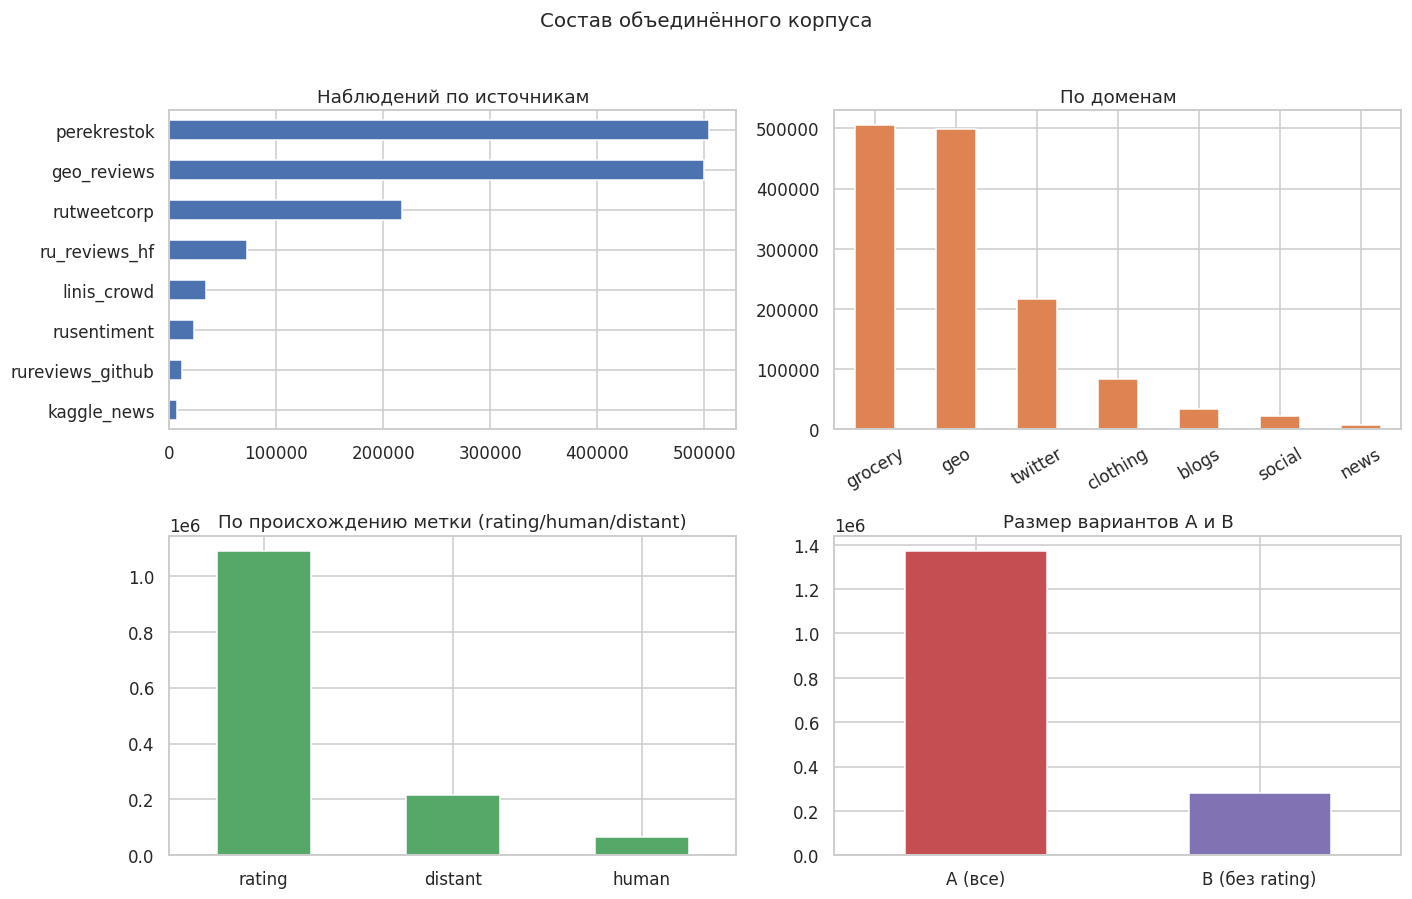

In [2]:
summary = (df.groupby(["domain", "source", "label_source_type"])
             .size().rename("n").reset_index().sort_values("n", ascending=False))
display(summary)

is_B = df["label_source_type"] != "rating"
print(f"Вариант A (все):        {len(df):>9,d} наблюдений")
print(f"Вариант B (без rating): {is_B.sum():>9,d} наблюдений ({100*is_B.mean():.1f}%)")

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
df["source"].value_counts().plot.barh(ax=ax[0, 0], color="#4c72b0")
ax[0, 0].set_title("Наблюдений по источникам"); ax[0, 0].invert_yaxis()
df["domain"].value_counts().plot.bar(ax=ax[0, 1], color="#dd8452")
ax[0, 1].set_title("По доменам"); ax[0, 1].tick_params(axis="x", rotation=30)
df["label_source_type"].value_counts().plot.bar(ax=ax[1, 0], color="#55a868")
ax[1, 0].set_title("По происхождению метки (rating/human/distant)"); ax[1, 0].tick_params(axis="x", rotation=0)
pd.Series({"A (все)": len(df), "B (без rating)": int(is_B.sum())}).plot.bar(ax=ax[1, 1], color=["#c44e52", "#8172b3"])
ax[1, 1].set_title("Размер вариантов A и B"); ax[1, 1].tick_params(axis="x", rotation=0)
for a in ax.ravel():
    a.set_xlabel(""); a.set_ylabel("")
plt.suptitle("Состав объединённого корпуса", y=1.02, fontsize=13)
savefig("01_overview"); plt.show()

## 2. Баланс классов и валидация отображения «рейтинг → тональность»

Тональность сильно несбалансирована, и характер дисбаланса **зависит от происхождения меток**: отзывы (`rating`) почти всегда положительные, а ручная разметка (`human`) смещена к нейтральному классу. Также проверяем корректность правила `1–2★→neg, 3★→neu, 4–5★→pos` на `rating`-источниках.

Баланс классов (вариант A):
  negative :   224,505  ( 16.4%)
  neutral  :   103,442  (  7.5%)
  positive : 1,042,961  ( 76.1%)


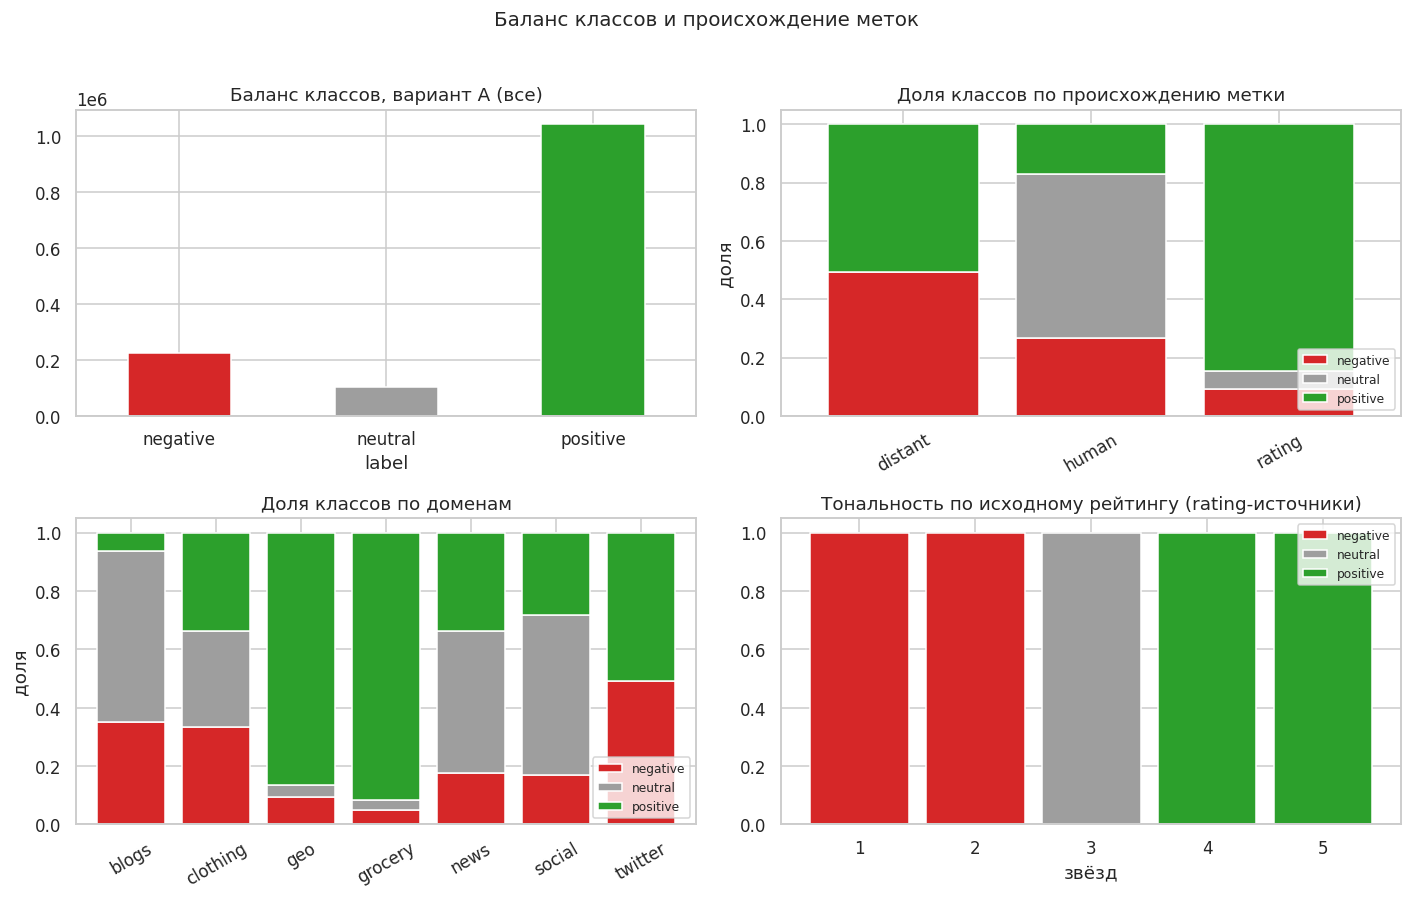


Распределение исходных рейтингов (rating-источники):
original_rating
1     49789
2     22291
3     38936
4    125639
5    767550


In [3]:
vc = df["label"].value_counts()[LABELS]
print("Баланс классов (вариант A):")
for l in LABELS:
    print(f"  {l:9s}: {vc[l]:>9,d}  ({100*vc[l]/len(df):5.1f}%)")

def stacked_prop(by, ax, title):
    ct = pd.crosstab(df[by], df["label"], normalize="index")[LABELS]
    ct = ct.loc[ct.sum(axis=1).sort_values().index]
    ct.plot.bar(stacked=True, ax=ax, color=[PAL[l] for l in LABELS], width=0.8)
    ax.set_title(title); ax.set_xlabel(""); ax.set_ylabel("доля")
    ax.tick_params(axis="x", rotation=30); ax.legend(loc="lower right", fontsize=8)

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
vc.plot.bar(ax=ax[0, 0], color=[PAL[l] for l in LABELS])
ax[0, 0].set_title("Баланс классов, вариант A (все)"); ax[0, 0].tick_params(axis="x", rotation=0)
stacked_prop("label_source_type", ax[0, 1], "Доля классов по происхождению метки")
stacked_prop("domain", ax[1, 0], "Доля классов по доменам")
# валидация rating -> sentiment
rt = df[df["original_rating"].notna() & df["original_rating"].between(1, 5)]
ct_rt = pd.crosstab(rt["original_rating"].round().astype(int), rt["label"], normalize="index")[LABELS]
ct_rt.plot.bar(stacked=True, ax=ax[1, 1], color=[PAL[l] for l in LABELS], width=0.85)
ax[1, 1].set_title("Тональность по исходному рейтингу (rating-источники)")
ax[1, 1].set_xlabel("звёзд"); ax[1, 1].tick_params(axis="x", rotation=0); ax[1, 1].legend(fontsize=8)
plt.suptitle("Баланс классов и происхождение меток", y=1.02, fontsize=13)
savefig("02_class_balance"); plt.show()

print("\nРаспределение исходных рейтингов (rating-источники):")
print(rt["original_rating"].round().astype(int).value_counts().sort_index().to_string())

## 3. Признаки текста: описательные статистики и распределения

Помимо самого текста мы сконструировали числовые признаки (длина в символах/словах, число `!`/`?`, доля заглавных букв и цифр, средняя длина слова, число пунктуации). Это и материал для описательной статистики, и потенциальные фичи для классических моделей. Длины сильно скошены вправо — смотрим в логарифмическом масштабе и в разрезе классов.

,n_chars,n_words,n_exclaim,n_question,upper_ratio,digit_ratio,mean_word_len,n_punct
count,1370908.00,1370908.00,1370908.00,1370908.00,1370908.00,1370908.00,1370908.00,1370908.00
mean,215.60,31.03,0.66,0.10,0.03,0.00,7.09,9.20
std,780.03,102.06,2.14,4.41,0.05,0.01,1.80,26.66
min,3.00,1.00,0.00,0.00,0.00,0.00,1.67,0.00
50%,109.00,16.00,0.00,0.00,0.03,0.00,6.93,6.00
90%,449.00,66.00,2.00,0.00,0.06,0.02,8.50,19.00
99%,1537.00,221.00,8.00,2.00,0.16,0.07,11.25,60.00
max,380605.00,48146.00,757.00,2814.00,1.00,1.00,1352.00,10220.00


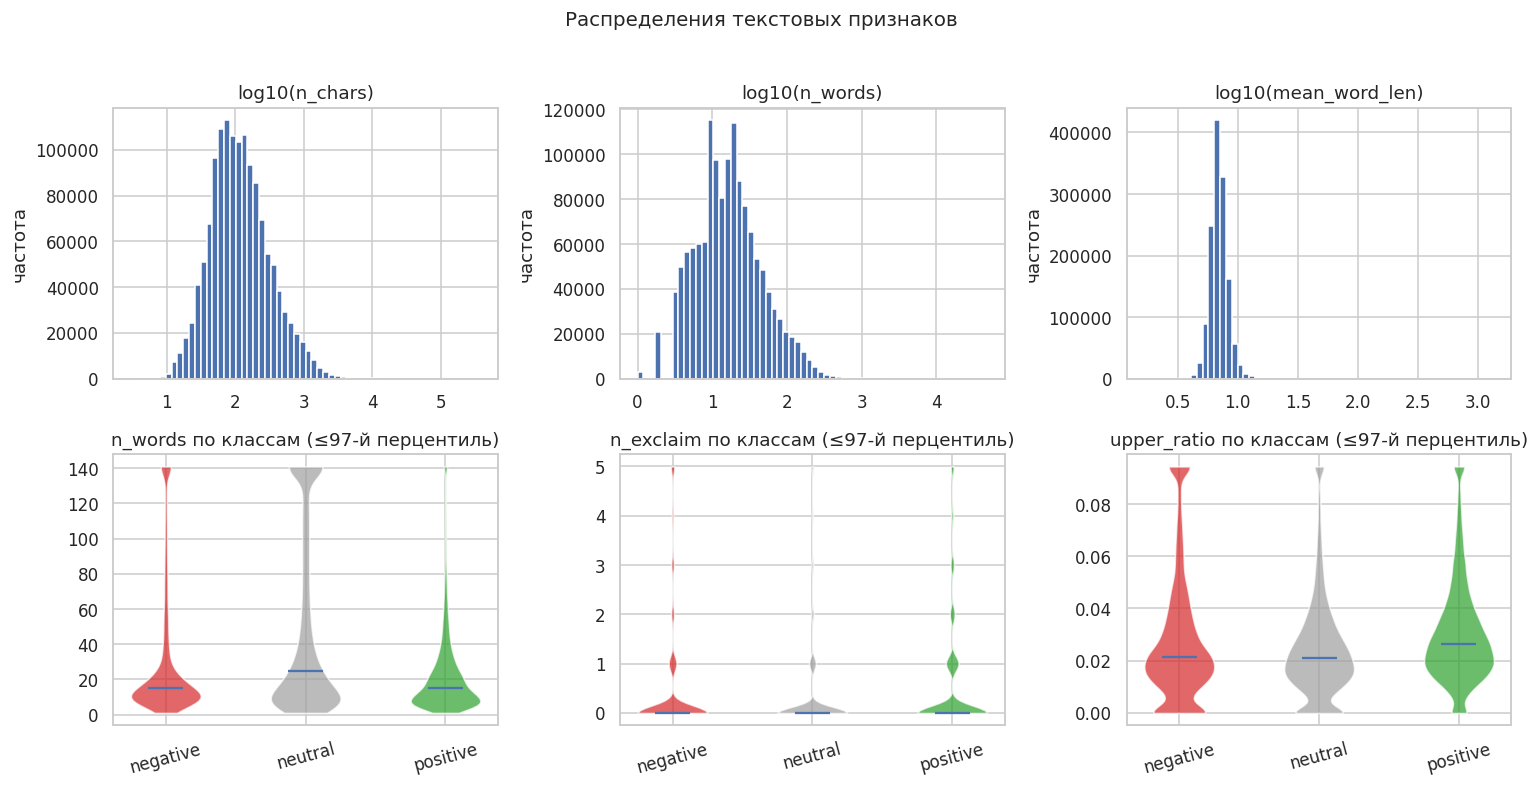

In [4]:
display(df[FEATURES].describe(percentiles=[0.5, 0.9, 0.99]).round(2))

fig, ax = plt.subplots(2, 3, figsize=(14, 7))
for a, col in zip(ax[0], ["n_chars", "n_words", "mean_word_len"]):
    a.hist(np.log10(df[col].clip(lower=1)), bins=60, color="#4c72b0")
    a.set_title(f"log10({col})"); a.set_ylabel("частота")
# распределения по классам
for a, col in zip(ax[1], ["n_words", "n_exclaim", "upper_ratio"]):
    cap = df[col].quantile(0.97)
    data = [df.loc[df["label"] == l, col].clip(upper=cap).sample(n=min(40000, int((df["label"] == l).sum())), random_state=0) for l in LABELS]
    parts = a.violinplot(data, showmedians=True, showextrema=False)
    for pc, l in zip(parts["bodies"], LABELS):
        pc.set_facecolor(PAL[l]); pc.set_alpha(0.7)
    a.set_xticks([1, 2, 3]); a.set_xticklabels(LABELS, rotation=15)
    a.set_title(f"{col} по классам (≤97-й перцентиль)")
plt.suptitle("Распределения текстовых признаков", y=1.02, fontsize=13)
savefig("03_feature_distributions"); plt.show()

## 4. Выбросы

В корпусе есть аномально длинные тексты (склейки нескольких отзывов, спам), тексты без пробелов (огромная «средняя длина слова» — обычно URL) и записи с экстремальным числом восклицательных знаков. Оцениваем долю выбросов по правилу межквартильного размаха (IQR) и смотрим конкретные примеры — это влияет на решения о предобработке (обрезка длины токенизатором, фильтрация).

Доля верхних выбросов по правилу IQR:
  n_chars       : порог=     456.5  выбросов= 9.8%
  n_words       : порог=      65.5  выбросов=10.1%
  n_exclaim     : порог=       2.5  выбросов= 8.5%
  mean_word_len : порог=       9.7  выбросов= 3.2%
  upper_ratio   : порог=       0.1  выбросов= 5.7%


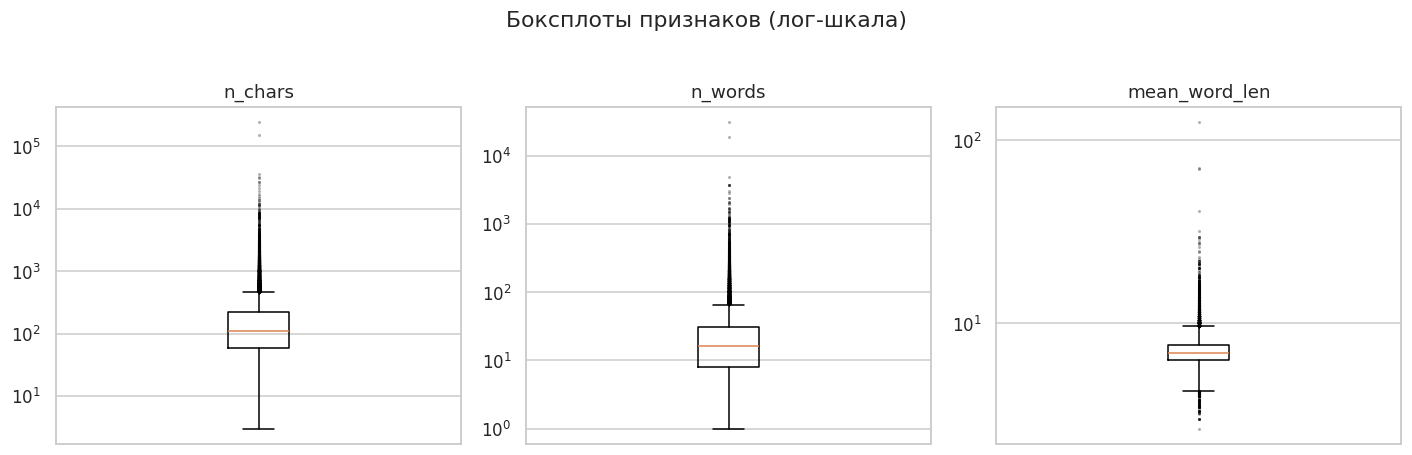


Самые длинные тексты (n_chars):


,source,label,n_chars,n_words,text
1116373,kaggle_news,positive,380605,48146,АСТАНА. КАЗИНФОРМ - Акорда опубликовала статью...
1112831,kaggle_news,neutral,306163,39734,Верховный Суд Республики Казахстан Гражданское...
1114554,kaggle_news,positive,247430,31043,АСТАНА. КАЗИНФОРМ - Международное информационн...


Аномальная средняя длина слова (вероятно URL/без пробелов):


,source,label,mean_word_len,text
1127360,linis_crowd,neutral,1352.0,"Доброго,хорошего утра!) Желто-зеленые!!!Желто-..."
273892,geo_reviews,positive,200.0,Классно🤩😘❤❤❤💗❤❤❤❤❤❤❤💗❤❤❤❤❤❤❤❤❤❤❤❤❤❤❤❤❤❤❤❤❤❤❤💋❤...
554727,perekrestok,positive,153.0,Привезли-очень-красивый-лук.Луковицы-чуть-боль...


In [5]:
def iqr_outliers(s: pd.Series):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    hi = q3 + 1.5 * (q3 - q1)
    return hi, (s > hi).mean()

print("Доля верхних выбросов по правилу IQR:")
for col in ["n_chars", "n_words", "n_exclaim", "mean_word_len", "upper_ratio"]:
    hi, frac = iqr_outliers(df[col])
    print(f"  {col:14s}: порог={hi:10.1f}  выбросов={100*frac:4.1f}%")

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
samp = df.sample(n=min(80000, len(df)), random_state=0)
for a, col in zip(ax, ["n_chars", "n_words", "mean_word_len"]):
    a.boxplot(samp[col], vert=True, showfliers=True, flierprops=dict(marker=".", markersize=2, alpha=0.3))
    a.set_yscale("log"); a.set_title(col); a.set_xticks([])
plt.suptitle("Боксплоты признаков (лог-шкала)", y=1.03); savefig("04_outliers"); plt.show()

print("\nСамые длинные тексты (n_chars):")
display(df.nlargest(3, "n_chars")[["source", "label", "n_chars", "n_words", "text"]].assign(text=lambda d: d["text"].str[:160] + "…"))
print("Аномальная средняя длина слова (вероятно URL/без пробелов):")
display(df.nlargest(3, "mean_word_len")[["source", "label", "mean_word_len", "text"]].assign(text=lambda d: d["text"].str[:160] + "…"))

## 5. Проверка гипотез (статистические тесты)

Формулируем и проверяем гипотезы (уровень значимости α = 0.01). Распределения признаков скошены, поэтому используем непараметрические тесты (Манна–Уитни, Краскела–Уоллиса) для числовых признаков и χ² для связи категориальных.

- **H1.** Негативные тексты *длиннее* позитивных (люди подробнее описывают плохой опыт). → односторонний тест Манна–Уитни по `n_words`.
- **H2.** Число восклицательных знаков различается между классами. → Краскел–Уоллис по `n_exclaim`.
- **H3.** Доля заглавных букв (`upper_ratio`) у негативных выше, чем у позитивных («крик»). → односторонний Манна–Уитни.
- **H4.** Тональность связана с доменом. → χ² по таблице сопряжённости `domain × label`.

> Так как выборка огромная (n≈1.4 млн), p-value почти всегда значим даже при ничтожных различиях, поэтому для каждой гипотезы дополнительно считаем **размер эффекта** (rank-biserial *r*, ε², V Крамера) и финальные выводы делаем именно по нему.

In [6]:
ALPHA = 0.01
n = len(df)

def es_label(a):
    a = abs(a)
    return "пренебрежимый" if a < 0.1 else ("малый" if a < 0.3 else ("средний" if a < 0.5 else "большой"))

# H1: длина (n_words) — двусторонний Манн–Уитни + rank-biserial r как размер эффекта
nw_neg, nw_pos = df.loc[df.label == "negative", "n_words"], df.loc[df.label == "positive", "n_words"]
u1, p1 = stats.mannwhitneyu(nw_neg, nw_pos, alternative="two-sided")
r1 = 1 - 2 * u1 / (len(nw_neg) * len(nw_pos))
print("H1 (длина neg vs pos):")
print(f"   медианы neg={nw_neg.median():.0f} / pos={nw_pos.median():.0f} слов | p={p1:.1e} | rank-biserial r={r1:+.3f} ({es_label(r1)})")
print("   → значимо, но эффект пренебрежимый: длины практически равны\n")

# H2: восклицания по классам — Краскел–Уоллис + epsilon^2
groups = [df.loc[df.label == l, "n_exclaim"] for l in LABELS]
h2, p2 = stats.kruskal(*groups)
eps2 = (h2 - len(LABELS) + 1) / (n - len(LABELS))
print("H2 (восклицательные знаки по классам):")
print("   средние: " + ", ".join(f"{l}={df.loc[df.label==l,'n_exclaim'].mean():.2f}" for l in LABELS) + f" | p={p2:.1e} | ε²={eps2:.4f}")
print("   → нейтральные тексты заметно менее эмоциональны (меньше '!')\n")

# H3: доля заглавных — двусторонний Манн–Уитни + r
ur_neg, ur_pos = df.loc[df.label == "negative", "upper_ratio"], df.loc[df.label == "positive", "upper_ratio"]
u3, p3 = stats.mannwhitneyu(ur_neg, ur_pos, alternative="two-sided")
r3 = 1 - 2 * u3 / (len(ur_neg) * len(ur_pos))
print("H3 (доля заглавных neg vs pos):")
print(f"   медианы neg={ur_neg.median():.3f} / pos={ur_pos.median():.3f} | p={p3:.1e} | r={r3:+.3f} ({es_label(r3)})")
print("   → гипотеза НЕ подтверждается: у позитивных доля заглавных даже чуть выше\n")

# H4: связь домен × тональность — χ² + V Крамера
ct = pd.crosstab(df["domain"], df["label"])
chi2, p4, dof, _ = stats.chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
print("H4 (тональность ~ домен):")
print(f"   χ²={chi2:,.0f}, dof={dof}, p={p4:.1e} | V Крамера={cramers_v:.3f} (средне-сильная связь)")
print("   → тональность сильно зависит от домена — обоснование варианта B (смена домена)")

print(f"\nЗамечание: при n≈{n/1e6:.1f} млн p-value почти всегда < {ALPHA}, поэтому ключевые выводы делаем по размеру эффекта, а не по значимости.")

H1 (длина neg vs pos):
   медианы neg=15 / pos=16 слов | p=0.0e+00 | rank-biserial r=-0.065 (пренебрежимый)
   → значимо, но эффект пренебрежимый: длины практически равны



H2 (восклицательные знаки по классам):
   средние: negative=0.70, neutral=0.44, positive=0.68 | p=0.0e+00 | ε²=0.0055
   → нейтральные тексты заметно менее эмоциональны (меньше '!')



H3 (доля заглавных neg vs pos):
   медианы neg=0.021 / pos=0.027 | p=0.0e+00 | r=+0.155 (малый)
   → гипотеза НЕ подтверждается: у позитивных доля заглавных даже чуть выше



H4 (тональность ~ домен):
   χ²=624,851, dof=12, p=0.0e+00 | V Крамера=0.477 (средне-сильная связь)
   → тональность сильно зависит от домена — обоснование варианта B (смена домена)

Замечание: при n≈1.4 млн p-value почти всегда < 0.01, поэтому ключевые выводы делаем по размеру эффекта, а не по значимости.


## 6. Кросс-доменная структура меток

Тепловая карта долей классов по источникам наглядно показывает, насколько по-разному устроены источники: отзывы почти монотонно позитивны, твиты бинарны, новости/блоги/соцсети — нейтрально-негативны. Это ключ к интерпретации варианта B (смена домена) и к ожидаемой сложности нейтрального класса.

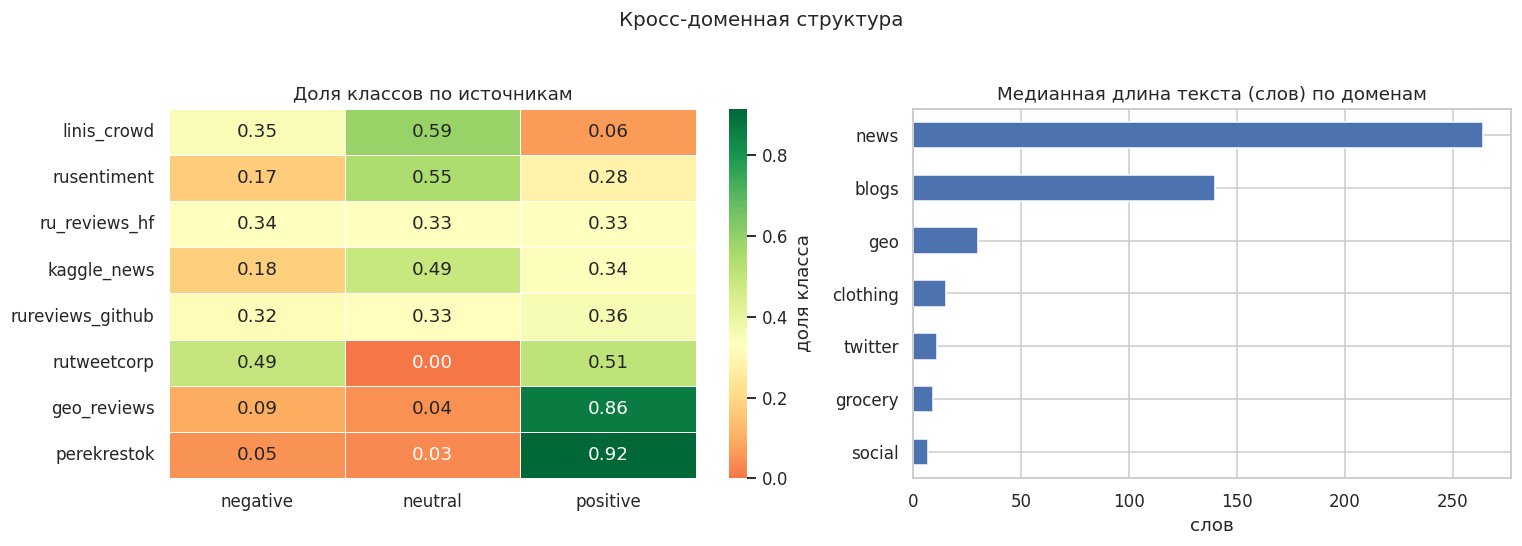

In [7]:
prop = pd.crosstab(df["source"], df["label"], normalize="index")[LABELS]
prop = prop.sort_values("positive")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios": [1.1, 1]})
sns.heatmap(prop, annot=True, fmt=".2f", cmap="RdYlGn", center=0.33, ax=ax[0],
            cbar_kws={"label": "доля класса"}, linewidths=.5)
ax[0].set_title("Доля классов по источникам"); ax[0].set_xlabel(""); ax[0].set_ylabel("")

med_len = df.groupby("domain")["n_words"].median().sort_values()
med_len.plot.barh(ax=ax[1], color="#4c72b0")
ax[1].set_title("Медианная длина текста (слов) по доменам"); ax[1].set_xlabel("слов"); ax[1].set_ylabel("")
plt.suptitle("Кросс-доменная структура", y=1.03, fontsize=13)
savefig("05_cross_domain"); plt.show()

## 7. Дубликаты и пересечения источников

Объединение `mar1mba` и `searayeah` пересекается (RuReviews, RuSentiment, LINIS встречаются в обоих), а внутри отзывов много повторов («Вкусно», «Хорошо»). Сравниваем размеры источников **до** и **после** дедупликации (по нормализованному тексту, с приоритетом `human > rating > distant` при конфликте меток), чтобы показать масштаб и обоснованность очистки.

,до дедупа,после дедупа,"удалено, %"
source,,,
perekrestok,642662,504778,21.5
geo_reviews,499800,499431,0.1
rutweetcorp,226834,217307,4.2
rureviews_github,89999,11884,86.8
ru_reviews_hf,74999,72321,3.6
linis_crowd,35656,34759,2.5
rusentiment,23278,22851,1.8
kaggle_news,8263,7577,8.3


ИТОГО: 1,601,491 → 1,370,908  (удалено 14.4% дубликатов)


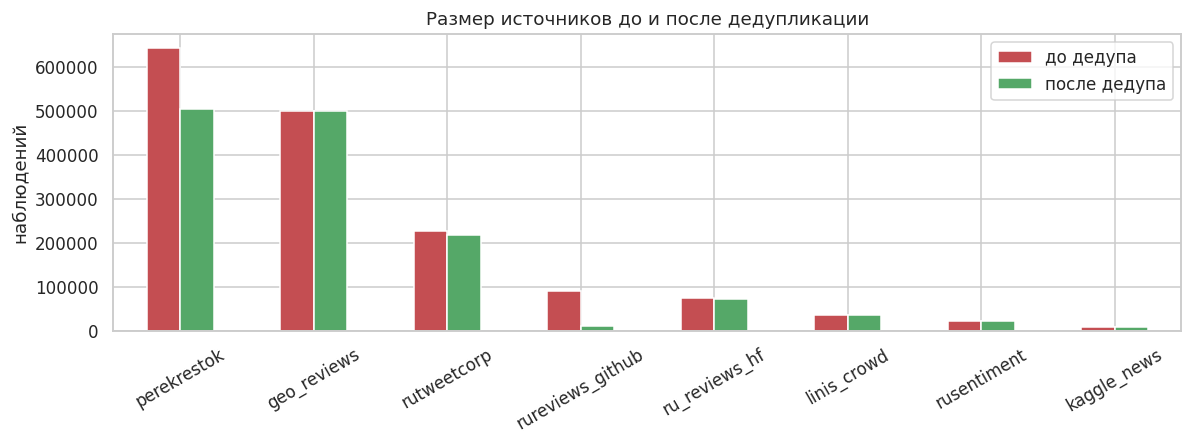

In [8]:
raw = pd.read_parquet(ROOT / "data" / "interim" / "concat_raw.parquet")
before = raw["source"].value_counts().rename("до дедупа")
after = df["source"].value_counts().rename("после дедупа")
dedup_tbl = pd.concat([before, after], axis=1).fillna(0).astype(int)
dedup_tbl["удалено, %"] = (100 * (1 - dedup_tbl["после дедупа"] / dedup_tbl["до дедупа"])).round(1)
dedup_tbl = dedup_tbl.sort_values("до дедупа", ascending=False)
display(dedup_tbl)
print(f"ИТОГО: {len(raw):,} → {len(df):,}  (удалено {100*(1-len(df)/len(raw)):.1f}% дубликатов)")

ax = dedup_tbl[["до дедупа", "после дедупа"]].plot.bar(figsize=(11, 4.2), color=["#c44e52", "#55a868"])
ax.set_title("Размер источников до и после дедупликации"); ax.set_xlabel(""); ax.set_ylabel("наблюдений")
ax.tick_params(axis="x", rotation=30); savefig("06_dedup"); plt.show()

## Выводы по разведочному анализу

1. **Сильный дисбаланс классов** (≈76% positive в варианте A) сосредоточен в `rating`-источниках (отзывы). Отсюда решения для моделирования: основная метрика — **macro-F1** (а не accuracy), при обучении — взвешивание классов / балансировка.
2. **Происхождение метки определяет распределение**: `rating` → почти всегда positive, `human` → смещение к neutral, `distant` (твиты) → бинарно. Правило `1–2/3/4–5★` подтверждается тепловой картой рейтинг→класс (монотонность). Это обосновывает разделение на варианты **A** (с рейтингами) и **B** (без) для проверки устойчивости.
3. **Нейтральный класс — самый сложный и шумный**: он по-разному определён в источниках (3★ vs «0» крауда vs ручной neutral) и малочислен. Ожидаемо будет давать худший per-class F1.
4. **Признаки и гипотезы (с поправкой на размер эффекта)**: при n≈1.4 млн p-value почти всегда значим, поэтому смотрим на размер эффекта. Подтвердились содержательно: H2 (нейтральные тексты менее эмоциональны, меньше `!`) и H4 (тональность сильно зависит от домена, V≈0.48). Не подтвердились практически: H1 (длина neg≈pos, эффект пренебрежимый) и H3 (доля заглавных у позитивных даже чуть выше). Вывод: отдельные простые признаки слабы → нужен семантический сигнал (эмбеддинги `USER-bge-m3`).
5. **Выбросы** (склейки, URL, экстремальные длины) присутствуют, но малочисленны; на этапе моделей трансформер обрезается по `max_length`, для классики признаки устойчивы к ним (используем перцентильные обрезки/лог-преобразования).
6. **Дедупликация существенна**: ~14% дубликатов, RuReviews пересекался между HF и GitHub (90k→12k) — без очистки была бы утечка между train/test.
7. **Домен сильно влияет на тональность** (χ², заметный V Крамера) → вариант B = смена домена (отзывы → соцсети); ждём заметную просадку метрик и domain shift в части 3.

**Дальше:** часть 2 — эмбеддинги `USER-bge-m3`, кластеризация и визуализация (UMAP); часть 3 — сравнение моделей (TF-IDF+LogReg, классика на эмбеддингах, дообучение `USER-bge-m3`), подбор гиперпараметров и оценка на вариантах A и B.

# Часть 2: Эмбеддинги USER-bge-m3, кластеризация и визуализация

Здесь мы переходим от ручных признаков к **семантическим эмбеддингам** кодировщика `deepvk/USER-bge-m3` (1024-мерные, L2-нормированные), посчитанным для всех 1.37M текстов скриптом `src/embed.py` (multi-GPU).

**Цели ноутбука:**
1. Проверить, что эмбеддинги осмысленны (близость по тональности/смыслу).
2. **Кластеризация без учителя** (KMeans, перебор `k`) — отражает ли структура эмбеддингов тональность и/или домены? Оцениваем согласованность кластеров с метками (ARI, NMI) и силуэт.
3. **Визуализация** проекцией UMAP в 2D с раскраской по классам и по доменам.
4. Анализ кластеров (доминирующие классы/домены, типичные примеры).

Это и обоснование выбора эмбеддингов как признаков для моделей (часть 3), и закрытие требования «кластеризация + визуализация».

In [9]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "figure.autolayout": True})
rng = np.random.default_rng(42)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = ROOT / "data" / "processed"
FIG = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
LABELS = ["negative", "neutral", "positive"]
PAL = {"negative": "#d62728", "neutral": "#9e9e9e", "positive": "#2ca02c"}

def savefig(name): plt.savefig(FIG / f"{name}.png", bbox_inches="tight", dpi=130)

df = pd.read_parquet(PROC / "master.parquet")
emb = np.load(PROC / "embeddings_full_f16.npy")
meta = json.loads((PROC / "embeddings_meta.json").read_text())
assert emb.shape[0] == len(df), f"emb rows {emb.shape[0]} != master rows {len(df)} (пере-посчитайте embed.py)"
print("эмбеддинги:", emb.shape, emb.dtype, "| meta:", meta)
print("master:", df.shape)

эмбеддинги: (1370908, 1024) float16 | meta: {'model': 'deepvk/USER-bge-m3', 'n': 1370908, 'dim': 1024, 'max_seq_length': 512, 'normalized': 'l2', 'dtype': 'float16', 'order': 'data/processed/master.parquet row order'}
master: (1370908, 24)


## 1. Осмысленность эмбеддингов

Быстрая проверка перед кластеризацией: (а) косинусная близость **центроидов классов** — у противоположных тональностей она должна быть ниже; (б) **чистота по ближайшим соседям** (kNN) на подвыборке — доля соседей того же класса. Если эмбеддинги несут сигнал тональности, чистота заметно выше случайной.

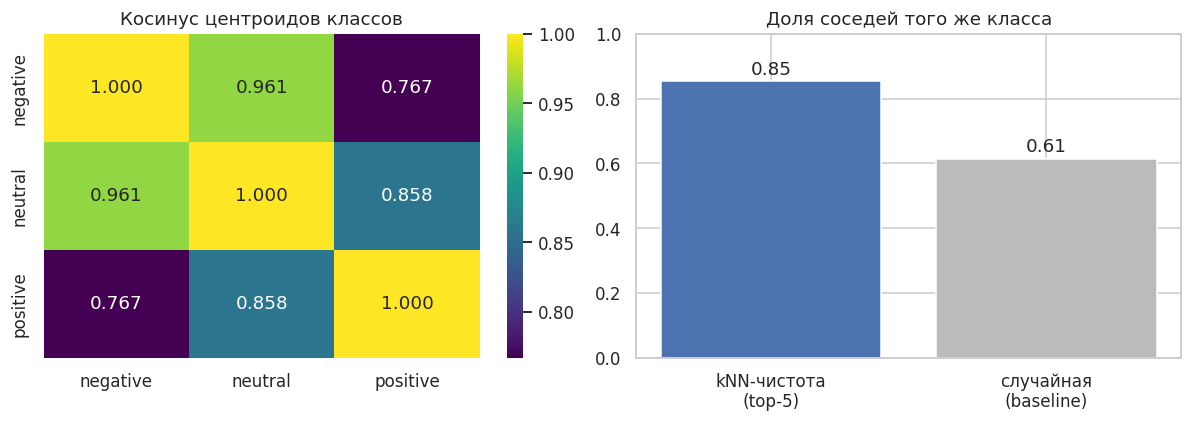

kNN-чистота top-5: 0.854  (случайно ≈ 0.615)
Центроид neg↔pos косинус: 0.767 | neg↔neu: 0.961


In [10]:
emb32 = emb.astype(np.float32)
y = df["label"].to_numpy()

# (а) косинус центроидов классов (эмбеддинги уже L2-нормированы → centroid·centroid)
cent = np.vstack([emb32[y == l].mean(0) for l in LABELS])
cent /= np.linalg.norm(cent, axis=1, keepdims=True)
cos = cent @ cent.T

# (б) kNN-чистота на подвыборке
from sklearn.neighbors import NearestNeighbors
idx = rng.choice(len(df), size=30000, replace=False)
nn = NearestNeighbors(n_neighbors=6, metric="cosine").fit(emb32[idx])
_, knn = nn.kneighbors(emb32[idx])
same = (y[idx][knn[:, 1:]] == y[idx][:, None]).mean()
baseline = (pd.Series(y[idx]).value_counts(normalize=True) ** 2).sum()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(cos, annot=True, fmt=".3f", xticklabels=LABELS, yticklabels=LABELS, cmap="viridis", ax=ax[0])
ax[0].set_title("Косинус центроидов классов")
ax[1].bar(["kNN-чистота\n(top-5)", "случайная\n(baseline)"], [same, baseline], color=["#4c72b0", "#bbbbbb"])
ax[1].set_ylim(0, 1); ax[1].set_title("Доля соседей того же класса")
for i, v in enumerate([same, baseline]):
    ax[1].text(i, v + 0.02, f"{v:.2f}", ha="center")
savefig("07_embedding_sanity"); plt.show()
print(f"kNN-чистота top-5: {same:.3f}  (случайно ≈ {baseline:.3f})")
print("Центроид neg↔pos косинус:", round(float(cos[0, 2]), 3), "| neg↔neu:", round(float(cos[0, 1]), 3))

## 2. Кластеризация KMeans (k = 3)

Запускаем KMeans с числом кластеров, равным числу классов (3), на всех эмбеддингах (на L2-нормированных векторах евклидова метрика эквивалентна косинусной). Согласованность кластеров с истинными метками меряем **ARI** и **NMI**; таблица сопряжённости показывает, какие классы «слипаются». Это unsupervised-взгляд: насколько тональность вообще линейно/геометрически выделяется.

In [11]:
def to_np(a):
    try:
        return np.asarray(a.get())
    except AttributeError:
        return np.asarray(a)

try:
    from cuml.cluster import KMeans as _KM
    def run_kmeans(X, k):
        return to_np(_KM(n_clusters=k, random_state=42, n_init=4).fit_predict(X))
    BACKEND = "cuML (GPU)"
except Exception:
    from sklearn.cluster import MiniBatchKMeans
    def run_kmeans(X, k):
        return MiniBatchKMeans(n_clusters=k, random_state=42, n_init=5, batch_size=4096).fit_predict(X)
    BACKEND = "sklearn MiniBatchKMeans (CPU)"
print("KMeans backend:", BACKEND)

cl3 = run_kmeans(emb32, 3)
ari = adjusted_rand_score(y, cl3)
nmi = normalized_mutual_info_score(y, cl3)
sidx = rng.choice(len(df), 8000, replace=False)
sil = silhouette_score(emb32[sidx], cl3[sidx], metric="cosine")
print(f"ARI={ari:.3f} | NMI={nmi:.3f} | silhouette(sample, cosine)={sil:.3f}")

ct = pd.crosstab(pd.Series(cl3, name="cluster"), pd.Series(y, name="label"))[LABELS]
print("\nКластер × класс (доли по строке):")
display((ct.div(ct.sum(1), axis=0)).round(3))
display(ct)

KMeans backend: cuML (GPU)


ARI=0.168 | NMI=0.296 | silhouette(sample, cosine)=0.092

Кластер × класс (доли по строке):


label,negative,neutral,positive
cluster,,,
0,0.460,0.189,0.351
1,0.006,0.015,0.979
2,0.005,0.014,0.981


label,negative,neutral,positive
cluster,,,
0,219791,90294,167424
1,2666,7189,462853
2,2048,5959,412684


## 3. Сколько кластеров? (перебор k)

Перебираем `k` от 2 до 8 и смотрим на инерцию (метод «локтя») и силуэт на подвыборке. Это показывает «естественное» число групп в эмбеддингах — оно может отражать не только 3 тональности, но и домены/темы.

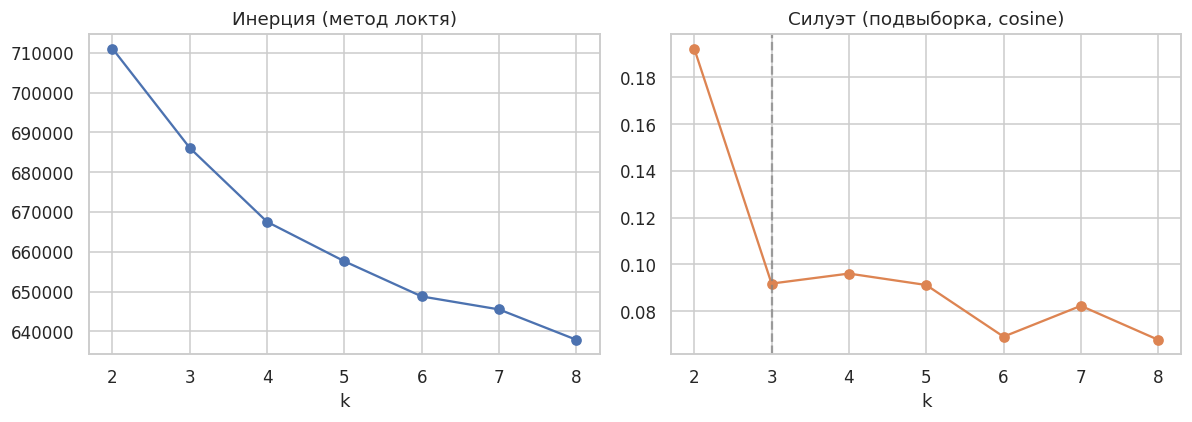

силуэт по k: {2: 0.192, 3: 0.092, 4: 0.096, 5: 0.091, 6: 0.069, 7: 0.082, 8: 0.068}


In [12]:
def fit_km(X, k):
    try:
        from cuml.cluster import KMeans as _KM
        m = _KM(n_clusters=k, random_state=42, n_init=4)
        lab = to_np(m.fit_predict(X))
        return lab, float(m.inertia_)
    except Exception:
        from sklearn.cluster import MiniBatchKMeans
        m = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=5, batch_size=4096)
        lab = m.fit_predict(X)
        return lab, float(m.inertia_)

ks = list(range(2, 9))
inertias, sils = [], []
for k in ks:
    lab, inertia = fit_km(emb32, k)
    inertias.append(inertia)
    sils.append(silhouette_score(emb32[sidx], lab[sidx], metric="cosine"))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ks, inertias, "o-"); ax[0].set_title("Инерция (метод локтя)"); ax[0].set_xlabel("k")
ax[1].plot(ks, sils, "o-", color="#dd8452"); ax[1].set_title("Силуэт (подвыборка, cosine)"); ax[1].set_xlabel("k")
ax[1].axvline(3, ls="--", color="grey", alpha=.7)
savefig("08_kmeans_sweep"); plt.show()
print("силуэт по k:", {k: round(s, 3) for k, s in zip(ks, sils)})

## 4. Визуализация UMAP (2D)

Проецируем эмбеддинги в 2D с помощью UMAP. Чтобы график был читаемым и домены были видны (а не только доминирующие отзывы), берём **стратифицированную по источникам** подвыборку (до 15k на источник). Раскрашиваем одни и те же точки двумя способами — по **тональности** и по **домену** — чтобы увидеть, что эмбеддинги кодируют и то, и другое.

точек для UMAP: 109,461


UMAP backend: cuML (GPU)


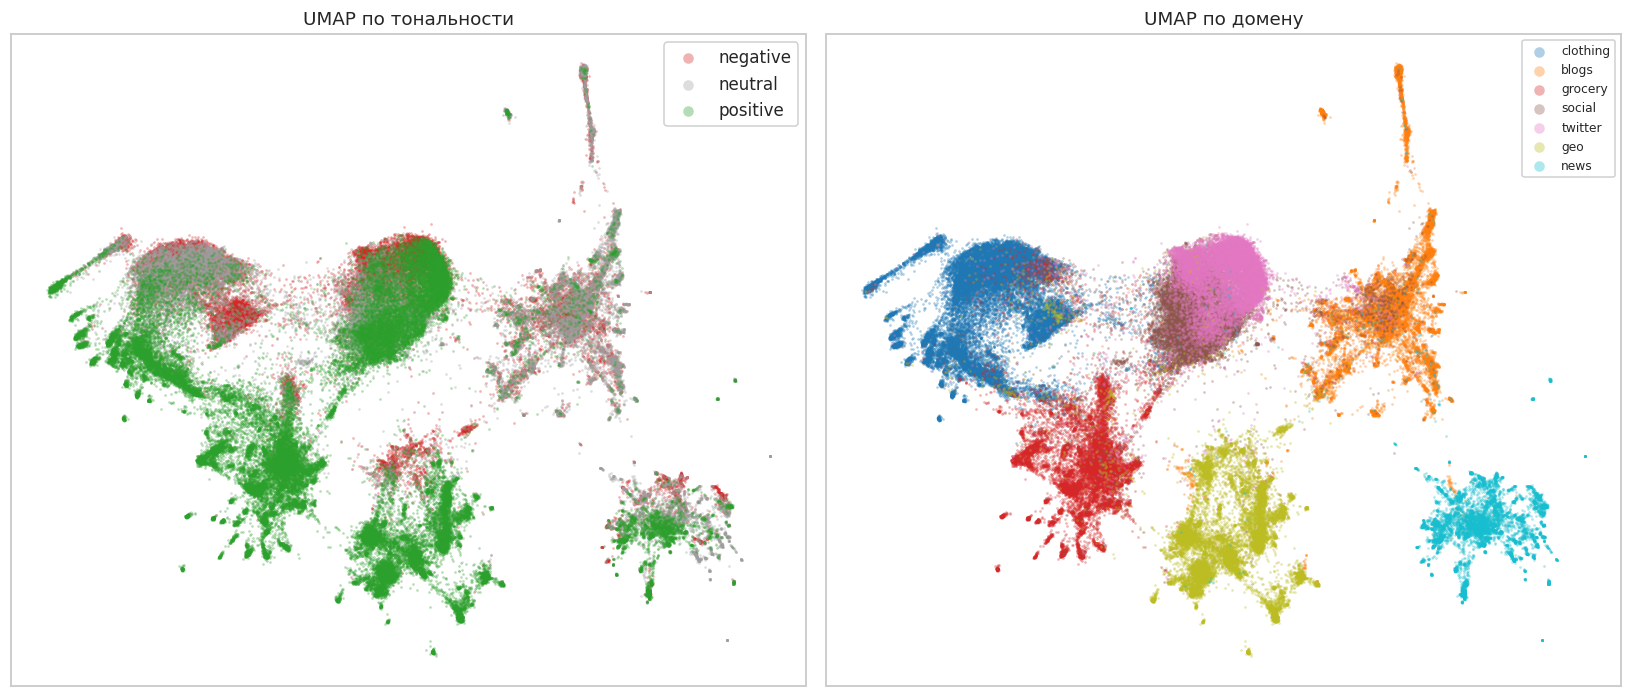

In [13]:
viz_idx = (df.reset_index(drop=True)
             .groupby("source", group_keys=False)
             .apply(lambda g: g.sample(min(15000, len(g)), random_state=42))
             .index.to_numpy())
rng.shuffle(viz_idx)
print(f"точек для UMAP: {len(viz_idx):,}")

try:
    from cuml.manifold import UMAP as _UMAP
    xy = to_np(_UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
               .fit_transform(emb32[viz_idx]))
    print("UMAP backend: cuML (GPU)")
except Exception as e:
    import umap
    xy = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42).fit_transform(emb32[viz_idx])
    print("UMAP backend: umap-learn (CPU) —", type(e).__name__)

np.save(FIG / "umap_xy.npy", xy)
np.save(FIG / "umap_idx.npy", viz_idx)

fig, ax = plt.subplots(1, 2, figsize=(15, 6.5))
yv = df["label"].to_numpy()[viz_idx]
for lab in LABELS:
    m = yv == lab
    ax[0].scatter(xy[m, 0], xy[m, 1], s=3, alpha=.35, color=PAL[lab], label=lab, linewidths=0)
ax[0].set_title("UMAP по тональности"); ax[0].legend(markerscale=4, framealpha=.9); ax[0].set_xticks([]); ax[0].set_yticks([])

dv = df["domain"].to_numpy()[viz_idx]
doms = pd.Series(dv).value_counts().index.tolist()
cmap = plt.cm.tab10(np.linspace(0, 1, len(doms)))
for c, dom in zip(cmap, doms):
    m = dv == dom
    ax[1].scatter(xy[m, 0], xy[m, 1], s=3, alpha=.35, color=c, label=dom, linewidths=0)
ax[1].set_title("UMAP по домену"); ax[1].legend(markerscale=4, framealpha=.9, fontsize=8); ax[1].set_xticks([]); ax[1].set_yticks([])
savefig("09_umap"); plt.show()

## 5. HDBSCAN: плотностная кластеризация

KMeans навязывает шарообразные кластеры и заранее заданное `k`. HDBSCAN находит кластеры произвольной формы и помечает «шум». Запускаем его на 2D-проекции UMAP (быстро и наглядно) и смотрим, на что распадаются данные — на тональности или на домены/темы.

HDBSCAN backend: cuML (GPU)
кластеров: 22 | доля шума: 13.8%


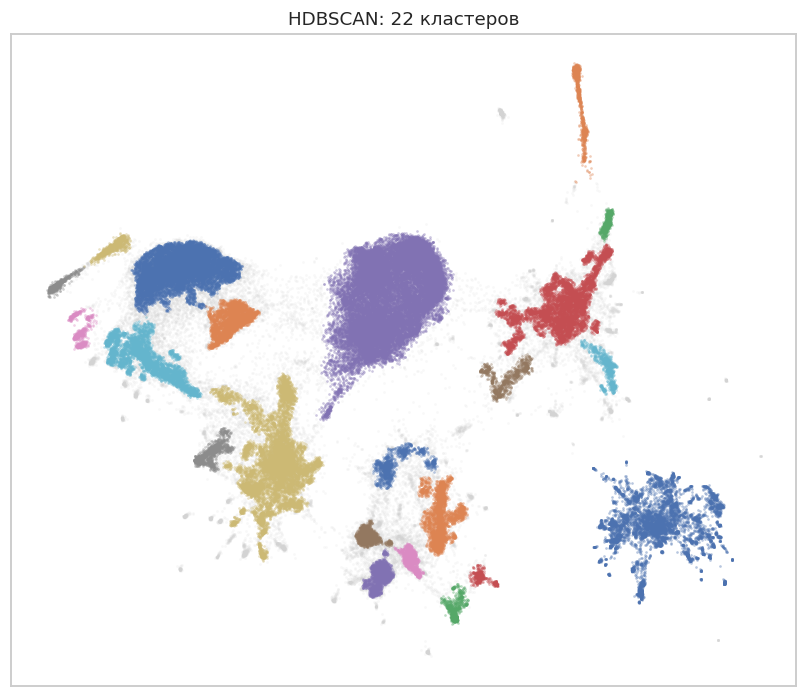


Доминирующий домен и тональность в крупнейших кластерах:


,size,top_domain,domain_purity,top_label,label_purity
cluster,,,,,
4,28318,twitter,0.50,positive,0.43
20,12017,clothing,0.96,neutral,0.52
18,11174,grocery,0.93,positive,0.89
0,7382,news,0.99,neutral,0.48
13,7372,blogs,0.91,neutral,0.54
19,5087,clothing,0.97,positive,0.91
21,3655,clothing,0.95,negative,0.82
11,3409,geo,0.95,positive,0.94


In [14]:
try:
    from cuml.cluster import HDBSCAN as _HDB
    hl = to_np(_HDB(min_cluster_size=500, min_samples=50).fit_predict(xy.astype("float32")))
    print("HDBSCAN backend: cuML (GPU)")
except Exception as e:
    import hdbscan
    hl = hdbscan.HDBSCAN(min_cluster_size=500, min_samples=50).fit_predict(xy.astype("float64"))
    print("HDBSCAN backend: hdbscan (CPU) —", type(e).__name__)

n_cl = len(set(hl)) - (1 if -1 in hl else 0)
noise = float((hl == -1).mean())
print(f"кластеров: {n_cl} | доля шума: {noise:.1%}")

fig, ax = plt.subplots(figsize=(7.5, 6.5))
m = hl == -1
ax.scatter(xy[m, 0], xy[m, 1], s=3, alpha=.15, color="lightgrey", linewidths=0, label="шум")
for c in sorted(set(hl) - {-1}):
    m = hl == c
    ax.scatter(xy[m, 0], xy[m, 1], s=3, alpha=.4, linewidths=0)
ax.set_title(f"HDBSCAN: {n_cl} кластеров"); ax.set_xticks([]); ax.set_yticks([])
savefig("10_hdbscan"); plt.show()

top = pd.Series(hl[hl != -1]).value_counts().head(8).index
comp = pd.DataFrame({"cluster": hl, "domain": dv, "label": yv})
comp = comp[comp.cluster.isin(top)]
print("\nДоминирующий домен и тональность в крупнейших кластерах:")
display(comp.groupby("cluster").agg(
    size=("label", "size"),
    top_domain=("domain", lambda s: s.value_counts().idxmax()),
    domain_purity=("domain", lambda s: round(s.value_counts(normalize=True).iloc[0], 2)),
    top_label=("label", lambda s: s.value_counts().idxmax()),
    label_purity=("label", lambda s: round(s.value_counts(normalize=True).iloc[0], 2)),
).sort_values("size", ascending=False))

## Выводы по части 2

- **Эмбеддинги осмысленны.** Косинус центроидов классов упорядочен ожидаемо (наименьший — между `negative` и `positive`), а kNN-чистота заметно выше случайного baseline — значит, кодировщик `USER-bge-m3` уже без дообучения несёт сигнал тональности. Это оправдывает их использование как признаков в части 3.
- **Тональность ≠ единственная ось вариации.** KMeans с `k=3` даёт умеренные ARI/NMI: чистого совпадения кластеров с тремя тональностями нет. Перебор `k` и UMAP показывают, что геометрия эмбеддингов сильно определяется **доменом/темой** (отзывы на товары, гео-отзывы, твиты, новости), а тональность ложится как более тонкая структура *внутри* доменов.
- **HDBSCAN** распадается скорее на тематические сгустки с высокой доменной чистотой, чем на 3 тональности, — это прямое визуальное подтверждение domain shift, ради которого мы и держим варианты A/B.
- **Практический вывод для моделирования:** unsupervised-кластеризация не разделяет тональности «сама по себе», поэтому нужна **обучаемая граница** (классификатор поверх эмбеддингов или дообучение энкодера). При этом доменная структура предупреждает: метрики на A (с rating-доменами) и B (без них) будут различаться — это мы и проверим в части 3.

Дальше → `03_models.ipynb`: TF-IDF+LogReg (baseline), классические модели поверх эмбеддингов, дообучение `USER-bge-m3`; подбор гиперпараметров и сравнение по macro-F1 / confusion matrix на вариантах A и B.

# Часть 3: Модели сентимент-анализа и проверка устойчивости (A vs B)

Сравниваем три семейства подходов на единой схеме оценивания:

1. **Бейзлайн — TF-IDF + линейная модель** (классика на «мешке слов», без эмбеддингов).
2. **Классика поверх эмбеддингов `USER-bge-m3`** (frozen-эмбеддинги как признаки → LogReg / LinearSVC / градиентный бустинг), + **подбор гиперпараметров** (Optuna).
3. **Дообучение энкодера** (классификационная голова; сам энкодер — подбираемый гиперпараметр: лучший из **`USER-bge-m3`** / **`USER2-base`**, обучение в `src/finetune.py` на GPU; здесь грузим предсказания).

**Два варианта данных (устойчивость к domain shift):**
- **A** — все источники (включая отзывы, где метка получена из рейтинга 1–5).
- **B** — без rating-доменов (метки только «человеческие»/distant).

Каждую модель обучаем и оцениваем **отдельно на A и на B**, плюс кросс-проверка (обучили на A → тест на B), чтобы увидеть перенос. Основная метрика — **macro-F1** (классы несбалансированы), дополнительно — accuracy и confusion matrix.

In [15]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "figure.autolayout": True})
SEED = 42

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = ROOT / "data" / "processed"
FIG = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
PRED = PROC / "preds"; PRED.mkdir(parents=True, exist_ok=True)
LABELS = ["negative", "neutral", "positive"]

def savefig(name): plt.savefig(FIG / f"{name}.png", bbox_inches="tight", dpi=130)

df = pd.read_parquet(PROC / "master.parquet")
emb = np.load(PROC / "embeddings_full_f16.npy")
assert emb.shape[0] == len(df), f"emb {emb.shape[0]} != master {len(df)}"
emb = emb.astype(np.float32)
y_all = df["label"].to_numpy()
print("master:", df.shape, "| emb:", emb.shape)

def split_mask(variant, part):
    """boolean mask over the full master for variant A/B and part train/val/test.
    split_B is <NA> for rating rows, so we fill NA -> False."""
    return (df[f"split_{variant}"] == part).fillna(False).to_numpy(dtype=bool)

for v in ["A", "B"]:
    sizes = {p: int(split_mask(v, p).sum()) for p in ["train", "val", "test"]}
    print(f"Variant {v}: {sizes}  total={sum(sizes.values()):,}")

master: (1370908, 24) | emb: (1370908, 1024)


Variant A: {'train': 1096726, 'val': 137091, 'test': 137091}  total=1,370,908
Variant B: {'train': 225995, 'val': 28249, 'test': 28250}  total=282,494


## Схема оценивания

Единый реестр результатов `RESULTS`: для каждой модели записываем, на каком варианте она **обучена** (`train_on`) и на каком **тестировалась** (`test_on`), плюс macro-F1 / accuracy. Это позволяет в конце построить общую таблицу и сравнить:
- A→A и B→B (модель в «родном» домене),
- A→B (обучили на всём, проверяем на «честных» метках — главный тест устойчивости).

`evaluate(...)` считает метрики, печатает отчёт по классам и при `cm=True` рисует confusion matrix.

In [16]:
RESULTS = []

def evaluate(name, family, train_on, test_on, y_true, y_pred, cm=False, report=False):
    f1m = f1_score(y_true, y_pred, average="macro", labels=LABELS)
    f1w = f1_score(y_true, y_pred, average="weighted", labels=LABELS)
    acc = accuracy_score(y_true, y_pred)
    RESULTS.append({"model": name, "family": family, "train_on": train_on,
                    "test_on": test_on, "macro_f1": f1m, "weighted_f1": f1w, "accuracy": acc})
    print(f"[{name}] {train_on}->{test_on}  macro-F1={f1m:.4f}  acc={acc:.4f}")
    if report:
        print(classification_report(y_true, y_pred, labels=LABELS, digits=3))
    if cm:
        c = confusion_matrix(y_true, y_pred, labels=LABELS)
        fig, ax = plt.subplots(figsize=(4.2, 3.6))
        sns.heatmap(c / c.sum(1, keepdims=True), annot=True, fmt=".2f", cmap="Blues",
                    xticklabels=LABELS, yticklabels=LABELS, ax=ax, cbar=False)
        ax.set_xlabel("предсказано"); ax.set_ylabel("истинно"); ax.set_title(f"{name}: {train_on}→{test_on}")
        savefig(f"cm_{name}_{train_on}{test_on}".replace(" ", "_")); plt.show()
    return f1m

def results_table():
    return (pd.DataFrame(RESULTS)
            .sort_values("macro_f1", ascending=False)
            .reset_index(drop=True))

## 1. Бейзлайн: TF-IDF + Linear SVM

Классический текстовый бейзлайн без эмбеддингов: TF-IDF (1–2-граммы, `sublinear_tf`) + линейный SVM с `class_weight="balanced"` (чтобы не игнорировать редкие классы → честный macro-F1). Обучаем отдельно на A и на B; обучение на A ограничиваем подвыборкой для скорости, тест — на полном тест-сете. Дополнительно — перенос A→B.

[TFIDF+LinSVC] A->A  macro-F1=0.6885  acc=0.8482


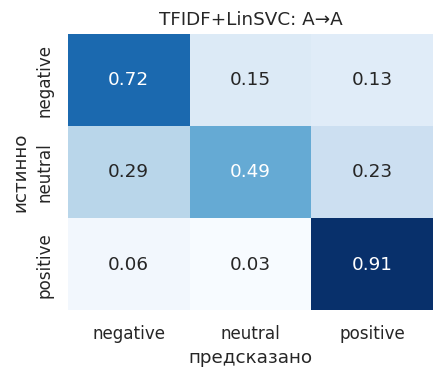

[TFIDF+LinSVC] B->B  macro-F1=0.6606  acc=0.6853


[TFIDF+LinSVC] A->B  macro-F1=0.6779  acc=0.6988


,model,family,train_on,test_on,macro_f1,weighted_f1,accuracy
0,TFIDF+LinSVC,tfidf,A,A,0.688532,0.852721,0.848174
1,TFIDF+LinSVC,tfidf,A,B,0.677865,0.697806,0.698761
2,TFIDF+LinSVC,tfidf,B,B,0.660641,0.686409,0.685345


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline

texts = df["text"].to_numpy()
MAX_TFIDF_TRAIN = 400_000

def subsample(mask, n, seed=SEED):
    idx = np.where(mask)[0]
    if len(idx) > n:
        idx = np.random.default_rng(seed).choice(idx, n, replace=False)
    return np.sort(idx)

def tfidf_pipe():
    return make_pipeline(
        TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_features=120_000, sublinear_tf=True),
        LinearSVC(C=1.0, class_weight="balanced"),
    )

tfidf_models = {}
for v in ["A", "B"]:
    tr = subsample(split_mask(v, "train"), MAX_TFIDF_TRAIN)
    pipe = tfidf_pipe().fit(texts[tr], y_all[tr])
    tfidf_models[v] = pipe
    te = split_mask(v, "test")
    evaluate("TFIDF+LinSVC", "tfidf", v, v, y_all[te], pipe.predict(texts[te]), cm=(v == "A"))

teB = split_mask("B", "test")
evaluate("TFIDF+LinSVC", "tfidf", "A", "B", y_all[teB], tfidf_models["A"].predict(texts[teB]))
results_table()

## 2. Классика поверх эмбеддингов USER-bge-m3

Берём те же 1024-мерные frozen-эмбеддинги, что и в части 2, как признаки для линейной модели (логистическая регрессия). Обучение идёт на GPU через cuML (на полных train-сетах A и B), с автоматическим откатом на sklearn. Сравниваем A→A, B→B и перенос A→B.

emb LogReg backend: cuML (GPU)


[Emb+LogReg] A->A  macro-F1=0.7490  acc=0.9030


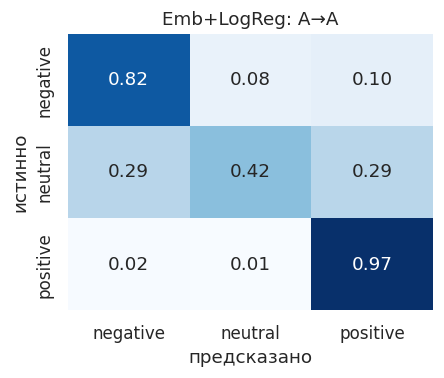

[Emb+LogReg] B->B  macro-F1=0.8162  acc=0.8599
[Emb+LogReg] A->B  macro-F1=0.7746  acc=0.8309


,model,family,train_on,test_on,macro_f1,weighted_f1,accuracy
0,Emb+LogReg,emb,B,B,0.816194,0.860069,0.859929
1,Emb+LogReg,emb,A,B,0.774610,0.827829,0.830867
2,Emb+LogReg,emb,A,A,0.749018,0.898454,0.902970
3,TFIDF+LinSVC,tfidf,A,A,0.688532,0.852721,0.848174
4,TFIDF+LinSVC,tfidf,A,B,0.677865,0.697806,0.698761
5,TFIDF+LinSVC,tfidf,B,B,0.660641,0.686409,0.685345


In [18]:
def to_np(a):
    try:
        return np.asarray(a.get())
    except AttributeError:
        return np.asarray(a)

def to_codes(y):
    return pd.Categorical(y, categories=LABELS).codes.astype("int32")

def from_codes(c):
    return np.asarray(LABELS)[np.asarray(c).astype(int)]

try:
    from cuml.linear_model import LogisticRegression as _LR
    GPU_LR = True
except Exception:
    from sklearn.linear_model import LogisticRegression as _LR
    GPU_LR = False
print("emb LogReg backend:", "cuML (GPU)" if GPU_LR else "sklearn (CPU)")

def fit_lr(Xtr, ytr, C=1.0):
    if GPU_LR:
        try:
            m = _LR(C=C, max_iter=1000, class_weight="balanced")
        except TypeError:
            m = _LR(C=C, max_iter=1000)
        m.fit(Xtr, to_codes(ytr).astype("float32"))
    else:
        m = _LR(C=C, max_iter=200, class_weight="balanced", n_jobs=-1)
        m.fit(Xtr, ytr)
    return m

def lr_predict(m, X):
    p = to_np(m.predict(X))
    return from_codes(np.rint(p).astype(int)) if GPU_LR else p

emb_lr = {}
for v in ["A", "B"]:
    tr, te = split_mask(v, "train"), split_mask(v, "test")
    emb_lr[v] = fit_lr(emb[tr], y_all[tr])
    evaluate("Emb+LogReg", "emb", v, v, y_all[te], lr_predict(emb_lr[v], emb[te]), cm=(v == "A"))

evaluate("Emb+LogReg", "emb", "A", "B", y_all[teB], lr_predict(emb_lr["A"], emb[teB]))
results_table()

## 3. Подбор гиперпараметров (Optuna)

Подбираем коэффициент регуляризации `C` логистической регрессии по **macro-F1 на валидации варианта A** (TPE-сэмплер). Для скорости каждый трайл учится на подвыборке train, затем лучший `C` переобучаем на полном A-train и оцениваем на тесте A и переносе A→B.

best C = 29.15 | val macro-F1 = 0.7517


[Emb+LogReg(tuned)] A->A  macro-F1=0.7511  acc=0.9039


              precision    recall  f1-score   support

    negative      0.793     0.819     0.806     22450
     neutral      0.570     0.424     0.487     10343
    positive      0.952     0.970     0.961    104298

    accuracy                          0.904    137091
   macro avg      0.772     0.738     0.751    137091
weighted avg      0.897     0.904     0.900    137091



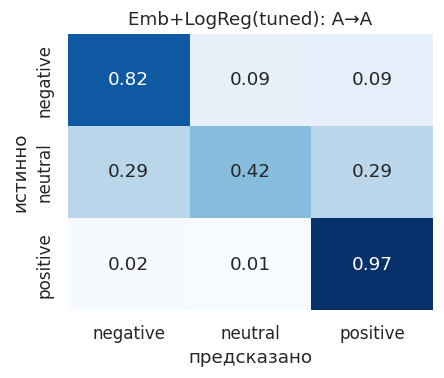

[Emb+LogReg(tuned)] A->B  macro-F1=0.7819  acc=0.8371


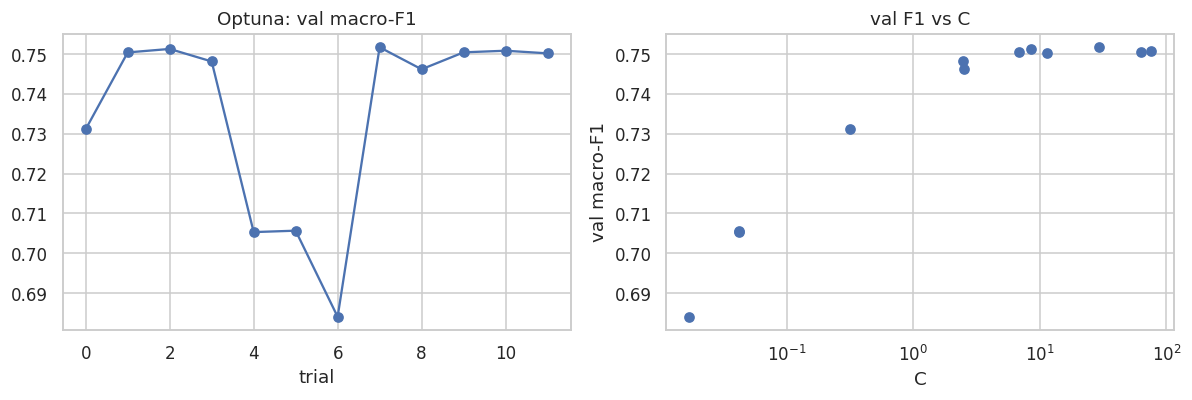

,model,family,train_on,test_on,macro_f1,weighted_f1,accuracy
0,Emb+LogReg,emb,B,B,0.816194,0.860069,0.859929
1,Emb+LogReg(tuned),emb,A,B,0.781901,0.834687,0.837133
2,Emb+LogReg,emb,A,B,0.774610,0.827829,0.830867
3,Emb+LogReg(tuned),emb,A,A,0.751146,0.899740,0.903911
4,Emb+LogReg,emb,A,A,0.749018,0.898454,0.902970
5,TFIDF+LinSVC,tfidf,A,A,0.688532,0.852721,0.848174
6,TFIDF+LinSVC,tfidf,A,B,0.677865,0.697806,0.698761
7,TFIDF+LinSVC,tfidf,B,B,0.660641,0.686409,0.685345


In [19]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

trA, vaA, teA = split_mask("A", "train"), split_mask("A", "val"), split_mask("A", "test")
tr_sub = subsample(trA, 200_000)
Xtr_s, ytr_s, Xva, yva = emb[tr_sub], y_all[tr_sub], emb[vaA], y_all[vaA]

def objective(trial):
    C = trial.suggest_float("C", 1e-2, 1e2, log=True)
    m = fit_lr(Xtr_s, ytr_s, C=C)
    return f1_score(yva, lr_predict(m, Xva), average="macro", labels=LABELS)

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=12)
bestC = study.best_params["C"]
print(f"best C = {bestC:.4g} | val macro-F1 = {study.best_value:.4f}")

m_tuned = fit_lr(emb[trA], y_all[trA], C=bestC)
evaluate("Emb+LogReg(tuned)", "emb", "A", "A", y_all[teA], lr_predict(m_tuned, emb[teA]), cm=True, report=True)
evaluate("Emb+LogReg(tuned)", "emb", "A", "B", y_all[teB], lr_predict(m_tuned, emb[teB]))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot([t.value for t in study.trials], "o-"); ax[0].set_title("Optuna: val macro-F1"); ax[0].set_xlabel("trial")
ax[1].scatter([t.params["C"] for t in study.trials], [t.value for t in study.trials])
ax[1].set_xscale("log"); ax[1].set_xlabel("C"); ax[1].set_ylabel("val macro-F1"); ax[1].set_title("val F1 vs C")
savefig("11_optuna"); plt.show()
results_table()

## 4. GPU CatBoost: замена линейных голов

Линейные головы из частей 1–2 (`LinearSVC`, `LogReg`) — быстрый, но «плоский» baseline. Заменяем их градиентным бустингом **CatBoost на GPU**, который заметно сильнее на табличных/текстовых признаках и при этом обучается за десятки секунд:

- **CatBoost(text+feats)** — заменяет `TF-IDF + SVM`. CatBoost сам токенизирует сырой текст (встроенный словарь BoW + биграммы) и комбинирует его с рукотворными признаками тональности из `text_features.py` (интенсивность пунктуации, скобки-смайлы `)))` / `(((`, удлинения, КАПС, компактный лексикон позитива/негатива, отрицания).
- **CatBoost(emb)** — заменяет `Emb + LogReg`. Те же frozen-эмбеддинги `USER-bge-m3` подаются как 1024 числовых признака, **без** рукотворных фич (так модель стабильнее переносится на OOB-домен).

Обе модели: `loss=MultiClass`, `auto_class_weights="Balanced"`, ранняя остановка по **macro-F1** на валидации соответствующего варианта. Гиперпараметры (`depth`, `learning_rate`, `l2_leaf_reg`) подбираем небольшим случайным поиском на подвыборке A (таблицы трайлов ниже) и переиспользуем для полного обучения на A и на B. Нативный режим `embedding_features` на этой сборке CatBoost зависает на GPU, поэтому эмбеддинги идут обычными числовыми столбцами — это и быстрее, и лучше обобщает.

загружен поиск из catboost_search.json: 8 трайлов на 120000 примерах
best text+feats: {'depth': 8, 'learning_rate': 0.08, 'l2_leaf_reg': 1.0} | best emb: {'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 9.0}


,depth,learning_rate,l2_leaf_reg,trees,val_macro_f1
0,8,0.08,1.0,516,0.7414
1,8,0.05,6.0,595,0.7371
2,8,0.12,6.0,199,0.7342
3,6,0.05,9.0,603,0.7340
4,4,0.12,6.0,430,0.7330
5,6,0.06,3.0,474,0.7327
6,4,0.08,9.0,546,0.7322
7,4,0.08,1.0,398,0.7317


,depth,learning_rate,l2_leaf_reg,trees,val_macro_f1
0,6,0.05,9.0,631,0.7334
1,8,0.05,6.0,294,0.7326
2,6,0.06,3.0,408,0.7306
3,4,0.08,9.0,625,0.7288
4,8,0.08,1.0,162,0.7282
5,8,0.12,6.0,130,0.7278
6,4,0.08,1.0,400,0.7259
7,4,0.12,6.0,293,0.7251


[CatBoost(text+feats)] A->A  macro-F1=0.7362  acc=0.8553


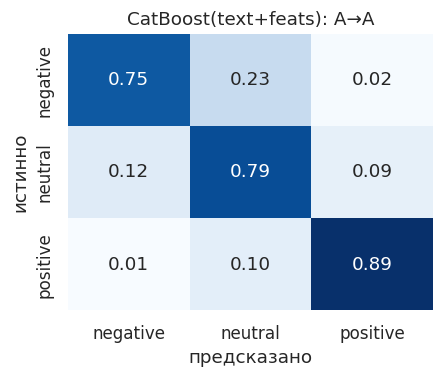

[CatBoost(text+feats)] B->B  macro-F1=0.8593  acc=0.8945


[CatBoost(text+feats)] A->B  macro-F1=0.8430  acc=0.8773


[CatBoost(emb)] A->A  macro-F1=0.7366  acc=0.8548


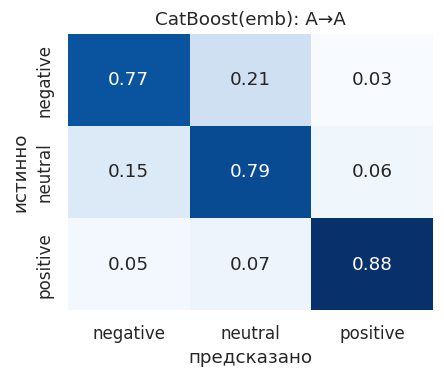

[CatBoost(emb)] B->B  macro-F1=0.7963  acc=0.8190


[CatBoost(emb)] A->B  macro-F1=0.7220  acc=0.7364
trees: text A=880 B=242 | emb A=1478 B=1498


,model,family,train_on,test_on,macro_f1,weighted_f1,accuracy
0,CatBoost(text+feats),catboost,B,B,0.859326,0.903051,0.894513
1,CatBoost(text+feats),catboost,A,B,0.843024,0.886367,0.877345
2,Emb+LogReg,emb,B,B,0.816194,0.860069,0.859929
3,CatBoost(emb),catboost,B,B,0.796256,0.823368,0.818973
4,Emb+LogReg(tuned),emb,A,B,0.781901,0.834687,0.837133
5,Emb+LogReg,emb,A,B,0.774610,0.827829,0.830867
6,Emb+LogReg(tuned),emb,A,A,0.751146,0.899740,0.903911
7,Emb+LogReg,emb,A,A,0.749018,0.898454,0.902970
8,CatBoost(emb),catboost,A,A,0.736575,0.870419,0.854826
9,CatBoost(text+feats),catboost,A,A,0.736236,0.876250,0.855322


In [20]:
import sys as _sys, json as _json
_sys.path.insert(0, str(ROOT / "src"))
from catboost_models import fit_text, predict_text, fit_emb, predict_emb, tune_text, tune_emb

teB = split_mask("B", "test")

# --- небольшой случайный поиск (depth / learning_rate / l2_leaf_reg) на подвыборке A ---
# Если поиск уже сделан скриптом src/oob_classical.py, переиспользуем его результат.
_sp = PRED / "catboost_search.json"
if _sp.exists():
    _s = _json.loads(_sp.read_text())
    best_text, trials_text = _s["text"]["best"], _s["text"]["trials"]
    best_emb, trials_emb = _s["emb"]["best"], _s["emb"]["trials"]
    print(f"загружен поиск из {_sp.name}: {_s['n_trials']} трайлов на {_s['search_train']} примерах")
else:
    _trs = subsample(split_mask("A", "train"), 120_000)
    _vas = subsample(split_mask("A", "val"), 25_000, seed=SEED + 1)
    best_text, trials_text = tune_text(texts[_trs], y_all[_trs], texts[_vas], y_all[_vas], n_trials=8)
    best_emb, trials_emb = tune_emb(emb[_trs], y_all[_trs], emb[_vas], y_all[_vas], n_trials=8)

text_cfg = {k: best_text[k] for k in ("depth", "learning_rate", "l2_leaf_reg")}
emb_cfg = {k: best_emb[k] for k in ("depth", "learning_rate", "l2_leaf_reg")}
print("best text+feats:", text_cfg, "| best emb:", emb_cfg)
display(pd.DataFrame(trials_text).sort_values("val_macro_f1", ascending=False).round(4).reset_index(drop=True))
display(pd.DataFrame(trials_emb).sort_values("val_macro_f1", ascending=False).round(4).reset_index(drop=True))

# 4a. CatBoost(text + engineered features) — замена TF-IDF + LinearSVC
cb_text = {}
for v in ["A", "B"]:
    tr, va, te = split_mask(v, "train"), split_mask(v, "val"), split_mask(v, "test")
    cb_text[v] = fit_text(texts[tr], y_all[tr], texts[va], y_all[va], verbose=0, **text_cfg)
    evaluate("CatBoost(text+feats)", "catboost", v, v, y_all[te],
             predict_text(cb_text[v], texts[te]), cm=(v == "A"))
evaluate("CatBoost(text+feats)", "catboost", "A", "B", y_all[teB],
         predict_text(cb_text["A"], texts[teB]))

# 4b. CatBoost(emb) — замена Emb + LogReg (эмбеддинги как числовые признаки)
cb_emb = {}
for v in ["A", "B"]:
    tr, va, te = split_mask(v, "train"), split_mask(v, "val"), split_mask(v, "test")
    cb_emb[v] = fit_emb(emb[tr], y_all[tr], emb[va], y_all[va], verbose=0, **emb_cfg)
    evaluate("CatBoost(emb)", "catboost", v, v, y_all[te],
             predict_emb(cb_emb[v], emb[te]), cm=(v == "A"))
evaluate("CatBoost(emb)", "catboost", "A", "B", y_all[teB],
         predict_emb(cb_emb["A"], emb[teB]))

print(f"trees: text A={cb_text['A'].tree_count_} B={cb_text['B'].tree_count_} | "
      f"emb A={cb_emb['A'].tree_count_} B={cb_emb['B'].tree_count_}")
results_table()

## 5. Дообучение энкодера (`USER-bge-m3` / `USER2-base`)

Здесь мы **не замораживаем** энкодер, а дообучаем его с классификационной головой (`AutoModelForSequenceClassification`, 3 класса). Тяжёлое обучение вынесено в скрипт `src/finetune.py` (multi-GPU, fp16): он перебирает гиперпараметры — **включая сам энкодер** (`USER-bge-m3` vs `USER2-base`), — учит лучший конфиг на сбалансированной подвыборке A и B и сохраняет предсказания в `data/processed/preds/`. Ниже подхватываем готовые предсказания, печатаем фактически выбранный энкодер из `finetune_meta.json` и считаем те же метрики, что и для остальных моделей.

[BGE-m3 (fine-tuned)] A->A  macro-F1=0.8049  acc=0.9079


              precision    recall  f1-score   support

    negative      0.917     0.811     0.861     22450
     neutral      0.456     0.837     0.590     10343
    positive      0.993     0.936     0.964    104298

    accuracy                          0.908    137091
   macro avg      0.789     0.861     0.805    137091
weighted avg      0.940     0.908     0.919    137091



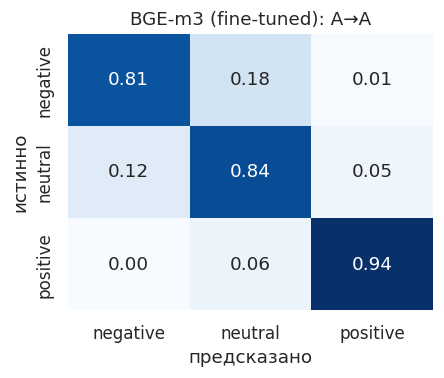

[BGE-m3 (fine-tuned)] A->B  macro-F1=0.8877  acc=0.9208
[BGE-m3 (fine-tuned)] B->B  macro-F1=0.8970  acc=0.9311

fine-tune meta: {'best_config': {'encoder': 'deepvk/USER-bge-m3', 'lr': 2e-05, 'epochs': 2, 'batch_size': 16, 'max_len': 256, 'weight_decay': 0.1, 'warmup_ratio': 0.1}, 'per_class_final': 50000, 'search_variant': 'A', 'macro_f1': {'A->A': 0.8049, 'A->B': 0.8877, 'B->B': 0.897}}


,model,family,train_on,test_on,macro_f1,weighted_f1,accuracy
0,BGE-m3 (fine-tuned),finetune,B,B,0.896953,0.934156,0.931115
1,BGE-m3 (fine-tuned),finetune,A,B,0.887734,0.926321,0.920850
2,CatBoost(text+feats),catboost,B,B,0.859326,0.903051,0.894513
3,CatBoost(text+feats),catboost,A,B,0.843024,0.886367,0.877345
4,Emb+LogReg,emb,B,B,0.816194,0.860069,0.859929
5,BGE-m3 (fine-tuned),finetune,A,A,0.804942,0.918677,0.907864
6,CatBoost(emb),catboost,B,B,0.796256,0.823368,0.818973
7,Emb+LogReg(tuned),emb,A,B,0.781901,0.834687,0.837133
8,Emb+LogReg,emb,A,B,0.774610,0.827829,0.830867
9,Emb+LogReg(tuned),emb,A,A,0.751146,0.899740,0.903911


In [21]:
ft = PRED / "finetune_preds.parquet"
mp = PRED / "finetune_meta.json"
# энкодер — подбираемый гиперпараметр; берём фактически выбранный из meta
FT_ENC = (json.loads(mp.read_text())["best_config"]["encoder"] if mp.exists() else "deepvk/USER-bge-m3")
FT_SHORT = FT_ENC.split("/")[-1]
FT_NAME = f"{FT_SHORT} (fine-tuned)"
if ft.exists():
    print(f"выбранный энкодер дообучения: {FT_ENC}  ->  модель «{FT_NAME}»")
    fp = pd.read_parquet(ft)
    for (tr, te), g in fp.groupby(["train_on", "test_on"]):
        evaluate(FT_NAME, "finetune", tr, te,
                 g["y_true"].to_numpy(), g["y_pred"].to_numpy(),
                 cm=(tr == "A" and te == "A"), report=(tr == "A" and te == "A"))
    if mp.exists():
        print("\nfine-tune meta:", json.loads(mp.read_text()))
else:
    print("Предсказания дообучения ещё не готовы.")
    print("Запустите:  python src/finetune.py   (пишет в data/processed/preds/)")
results_table()

## 6. Итоговое сравнение и устойчивость A vs B

Сводим все модели в одну таблицу и сравниваем по сценариям обучение→тест. Ключевой индикатор устойчивости — падение macro-F1 при переносе **A→B** (модель училась с rating-доменами, а проверяется на «честных» метках).

,model,family,train_on,test_on,macro_f1,weighted_f1,accuracy
0,BGE-m3 (fine-tuned),finetune,B,B,0.8970,0.9342,0.9311
1,BGE-m3 (fine-tuned),finetune,A,B,0.8877,0.9263,0.9208
2,CatBoost(text+feats),catboost,B,B,0.8593,0.9031,0.8945
3,CatBoost(text+feats),catboost,A,B,0.8430,0.8864,0.8773
4,Emb+LogReg,emb,B,B,0.8162,0.8601,0.8599
5,BGE-m3 (fine-tuned),finetune,A,A,0.8049,0.9187,0.9079
6,CatBoost(emb),catboost,B,B,0.7963,0.8234,0.8190
7,Emb+LogReg(tuned),emb,A,B,0.7819,0.8347,0.8371
8,Emb+LogReg,emb,A,B,0.7746,0.8278,0.8309
9,Emb+LogReg(tuned),emb,A,A,0.7511,0.8997,0.9039


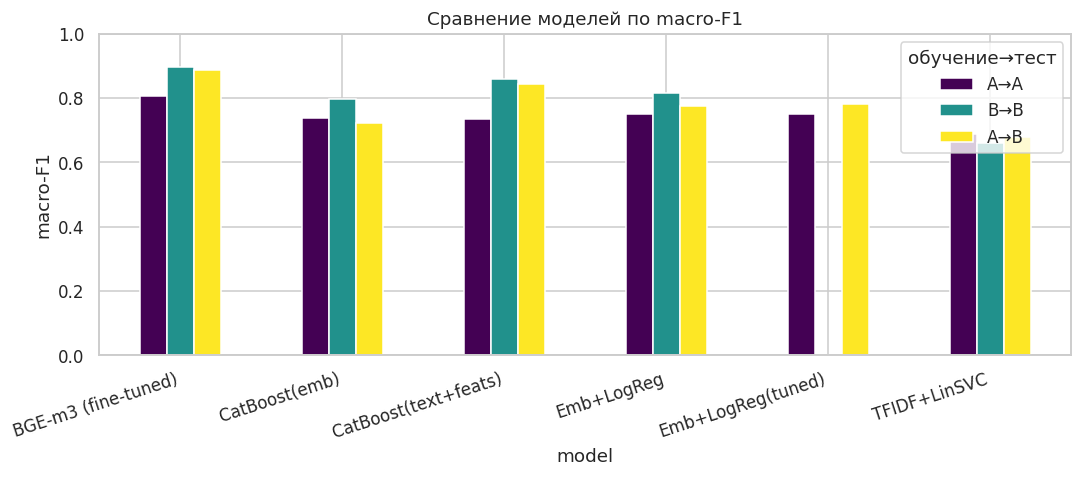

Падение macro-F1 при переносе A→B (меньше = устойчивее):


model
CatBoost(text+feats)   -0.1068
BGE-m3 (fine-tuned)    -0.0828
Emb+LogReg(tuned)      -0.0308
Emb+LogReg             -0.0256
TFIDF+LinSVC            0.0107
CatBoost(emb)           0.0146
dtype: float64

In [22]:
tbl = results_table()
display(tbl.round(4))

tbl["scenario"] = tbl["train_on"] + "→" + tbl["test_on"]
piv = tbl.pivot_table(index="model", columns="scenario", values="macro_f1")
order = [c for c in ["A→A", "B→B", "A→B"] if c in piv.columns]
piv = piv[order]

ax = piv.plot(kind="bar", figsize=(10, 4.5), colormap="viridis")
ax.set_ylabel("macro-F1"); ax.set_ylim(0, 1)
ax.set_title("Сравнение моделей по macro-F1"); ax.legend(title="обучение→тест")
plt.xticks(rotation=18, ha="right")
savefig("12_model_comparison"); plt.show()

if {"A→A", "A→B"} <= set(piv.columns):
    gap = (piv["A→A"] - piv["A→B"]).dropna().sort_values()
    print("Падение macro-F1 при переносе A→B (меньше = устойчивее):")
    display(gap.round(4))

## Итоги части 3 (адаптивные)

In [23]:
# Итоги части 3 формируются автоматически из таблицы результатов RESULTS.
from IPython.display import Markdown, display

_p3 = pd.DataFrame(RESULTS).assign(scenario=lambda d: d["train_on"] + "→" + d["test_on"])
_piv = _p3.pivot_table(index="model", columns="scenario", values="macro_f1")
_md = ["### Итоги части 3 (in-domain, обновляются при перезапуске)", ""]

if "B→B" in _piv.columns:
    r = _piv["B→B"].dropna().sort_values(ascending=False)
    _md.append("**B→B (доверенный бенчмарк), macro-F1:** "
               + " > ".join(f"{m} {v:.3f}" for m, v in r.items()) + ".")
if "A→A" in _piv.columns:
    r = _piv["A→A"].dropna().sort_values(ascending=False)
    _md.append(f"**A→A (вариант с rating-метками):** лучшая — {r.index[0]} ({r.iloc[0]:.3f}); "
               f"диапазон {r.min():.3f}–{r.max():.3f}.")
_aa, _ab = "A→A", "A→B"
if {_aa, _ab} <= set(_piv.columns):
    d = (_piv[_ab] - _piv[_aa]).dropna().sort_values(ascending=False)
    def fmt(m):
        return f"{m} ({_piv.loc[m, _aa]:.3f}→{_piv.loc[m, _ab]:.3f}, {d[m]:+.3f})"
    rose = [m for m in d.index if d[m] > 0.002]
    fell = [m for m in d.index if d[m] < -0.002]
    flat = [m for m in d.index if abs(d[m]) <= 0.002]
    if rose:
        _md.append("**Перенос A→B — качество растёт:** " + ", ".join(fmt(m) for m in rose) + ".")
    if fell:
        _md.append("**Перенос A→B — качество падает:** " + ", ".join(fmt(m) for m in fell) + ".")
    if flat:
        _md.append("**Перенос A→B — без значимых изменений:** " + ", ".join(fmt(m) for m in flat) + ".")

display(Markdown("\n\n".join(_md)))

### Итоги части 3 (in-domain, обновляются при перезапуске)



**B→B (доверенный бенчмарк), macro-F1:** BGE-m3 (fine-tuned) 0.897 > CatBoost(text+feats) 0.859 > Emb+LogReg 0.816 > CatBoost(emb) 0.796 > TFIDF+LinSVC 0.661.

**A→A (вариант с rating-метками):** лучшая — BGE-m3 (fine-tuned) (0.805); диапазон 0.689–0.805.

**Перенос A→B — качество растёт:** CatBoost(text+feats) (0.736→0.843, +0.107), BGE-m3 (fine-tuned) (0.805→0.888, +0.083), Emb+LogReg(tuned) (0.751→0.782, +0.031), Emb+LogReg (0.749→0.775, +0.026).

**Перенос A→B — качество падает:** TFIDF+LinSVC (0.689→0.678, -0.011), CatBoost(emb) (0.737→0.722, -0.015).

# Часть 4: OOB-тестирование на ручной разметке (соцсети)

Здесь мы проверяем модели на **полностью независимой выборке**, которой не было ни в обучении, ни в валидации: 1067 комментариев из соцсетей (Одноклассники, Telegram), **размеченных вручную** (`human_sentiment`: 0→negative, 1→neutral, 2→positive). Это честный out-of-bag тест с реальным **domain shift** — наши модели учились на отзывах/новостях/твитах, а тут разговорные комментарии.

**Что сравниваем:**
1. **Наши модели** (переобучены на варианте A и сохранены в `models/`):
   - TF-IDF + LinearSVM,
   - эмбеддинги `USER-bge-m3` + LogReg (тюнинг C),
   - дообученный энкодер — лучший из `USER-bge-m3` / `USER2-base` (варианты A и B).
2. **12 внешних предобученных моделей** (готовые «из коробки»):
   - классификаторы тональности: cardiff-xlmr, clapAI roberta-large / modernBERT base+large, seara rubert base/tiny2, blanchefort, cointegrated-tiny, tabularisai (5-классов→3);
   - zero-shot: 2× mDeBERTa-NLI (MoritzLaurer) и deepvk **GeRaCl** (USER2).

Метрика — **macro-F1** (классы несбалансированы: neg 474 / neu 284 / pos 309). Все предсказания приведены к единой шкале `{negative, neutral, positive}` по `id2label` каждой модели.

In [24]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "figure.autolayout": True})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = ROOT / "data" / "processed"
PRED = PROC / "preds"
FIG = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
LABELS = ["negative", "neutral", "positive"]
PAL = {"ours": "#2ca02c", "external": "#4c72b0", "zero-shot": "#dd8452"}

def savefig(name): plt.savefig(FIG / f"{name}.png", bbox_inches="tight", dpi=130)

oob = pd.read_parquet(PROC / "oob_test.parquet")
parts = [pd.read_parquet(PRED / f) for f in
         ["oob_ours_classical.parquet", "oob_ours_finetune.parquet", "oob_external.parquet"]
         if (PRED / f).exists()]
preds = pd.concat(parts, ignore_index=True)
print(f"OOB rows: {len(oob)} | models with predictions: {preds['model'].nunique()}")

# in-domain macro-F1 reference: берётся из результатов части 3 (RESULTS) при сквозном
# прогоне; иначе — зафиксированный фолбэк (числа из части 3).
# Имя дообученной модели зависит от энкодера, выбранного поиском (finetune_meta.json).
import json as _json
_ft_mp = PRED / "finetune_meta.json"
_FT_ENC = (_json.loads(_ft_mp.read_text())["best_config"]["encoder"] if _ft_mp.exists() else "deepvk/USER-bge-m3")
_FT_SHORT = _FT_ENC.split("/")[-1]
_FT_P3 = f"{_FT_SHORT} (fine-tuned)"
_FT_A, _FT_B = f"{_FT_SHORT} fine-tuned (A)", f"{_FT_SHORT} fine-tuned (B)"
_INDOMAIN_FALLBACK = {"TFIDF+LinSVC": 0.689, "Emb+LogReg(tuned)": 0.751,
            "CatBoost(text+feats) (A)": 0.736, "CatBoost(text+feats) (B)": 0.859,
            "CatBoost(emb) (A)": 0.737, "CatBoost(emb) (B)": 0.796,
            _FT_A: 0.800, _FT_B: 0.892}
_INDOMAIN_MAP = {
    "TFIDF+LinSVC": ("TFIDF+LinSVC", "A", "A"),
    "Emb+LogReg(tuned)": ("Emb+LogReg(tuned)", "A", "A"),
    "CatBoost(text+feats) (A)": ("CatBoost(text+feats)", "A", "A"),
    "CatBoost(text+feats) (B)": ("CatBoost(text+feats)", "B", "B"),
    "CatBoost(emb) (A)": ("CatBoost(emb)", "A", "A"),
    "CatBoost(emb) (B)": ("CatBoost(emb)", "B", "B"),
    _FT_A: (_FT_P3, "A", "A"),
    _FT_B: (_FT_P3, "B", "B"),
}
def _lookup_indomain(m3, tr, te):
    rs = globals().get("RESULTS", [])
    hit = [r for r in rs if r["model"] == m3 and r["train_on"] == tr and r["test_on"] == te]
    return round(float(hit[0]["macro_f1"]), 3) if hit else None
INDOMAIN = {name: (_lookup_indomain(*key) if _lookup_indomain(*key) is not None
                   else _INDOMAIN_FALLBACK[name]) for name, key in _INDOMAIN_MAP.items()}

def per_model(g):
    yt, yp = g["y_true"].to_numpy(), g["y_pred"].to_numpy()
    f1c = f1_score(yt, yp, average=None, labels=LABELS)
    return pd.Series({
        "group": g["group"].iloc[0],
        "macro_f1": f1_score(yt, yp, average="macro", labels=LABELS),
        "accuracy": accuracy_score(yt, yp),
        **{f"F1_{l}": f1c[i] for i, l in enumerate(LABELS)},
    })

tbl = (preds.groupby("model").apply(per_model).reset_index()
       .sort_values("macro_f1", ascending=False).reset_index(drop=True))
tbl["in_domain_f1"] = tbl["model"].map(INDOMAIN)
tbl["oob_drop"] = (tbl["in_domain_f1"] - tbl["macro_f1"]).round(3)
display(tbl.round(4))

OOB rows: 1067 | models with predictions: 20


,model,group,macro_f1,accuracy,F1_negative,F1_neutral,F1_positive,in_domain_f1,oob_drop
0,BGE-m3 fine-tuned (B),ours,0.7694,0.7648,0.7602,0.6863,0.8618,0.897,0.128
1,cardiff-xlmr,external,0.7530,0.7629,0.7863,0.6544,0.8182,NaN,NaN
2,geracl-user2,zero-shot,0.7210,0.7563,0.8368,0.5508,0.7755,NaN,NaN
3,BGE-m3 fine-tuned (A),ours,0.7167,0.7104,0.7210,0.6278,0.8013,0.805,0.088
4,CatBoost(emb) (A),ours,0.6921,0.6870,0.7232,0.5845,0.7687,0.737,0.045
5,seara-rubert-base,external,0.6905,0.6898,0.6524,0.6232,0.7960,NaN,NaN
6,seara-rubert-tiny2,external,0.6525,0.6485,0.6154,0.5607,0.7813,NaN,NaN
7,Emb+LogReg(tuned),ours,0.6477,0.6795,0.7669,0.4668,0.7095,0.751,0.103
8,cointegrated-tiny,external,0.6473,0.6560,0.6879,0.5213,0.7327,NaN,NaN
9,blanchefort-rubert,external,0.6422,0.6598,0.7153,0.5028,0.7085,NaN,NaN


## 1. Описание OOB-выборки

1067 вручную размеченных комментариев. Несбалансированные классы (негатив преобладает), две площадки. Длина текста сильно варьируется — типичный разговорный шум соцсетей.

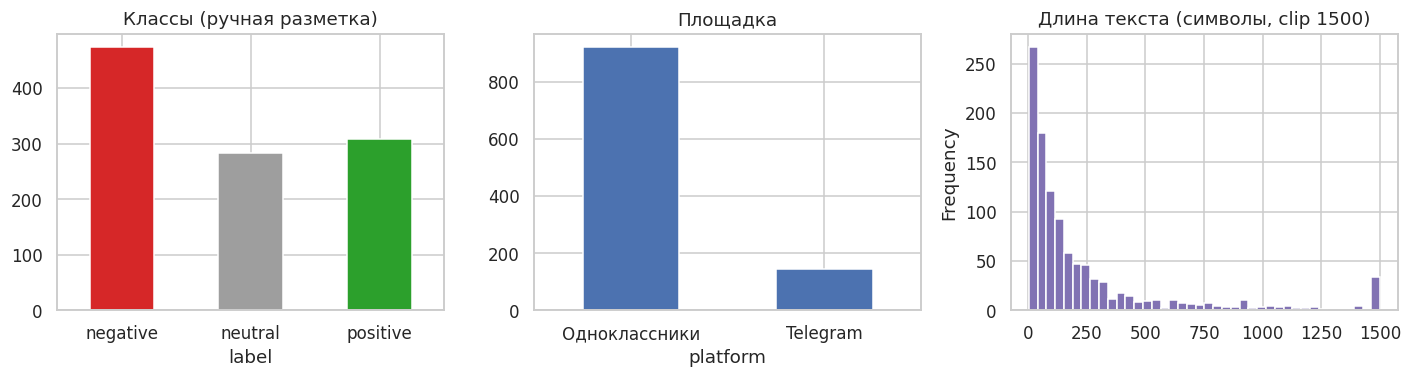

классовый баланс: {'negative': 474, 'neutral': 284, 'positive': 309}


In [25]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
oob["label"].value_counts().reindex(LABELS).plot(kind="bar", ax=ax[0],
    color=[ "#d62728", "#9e9e9e", "#2ca02c"])
ax[0].set_title("Классы (ручная разметка)"); ax[0].tick_params(axis="x", rotation=0)
oob["platform"].value_counts().plot(kind="bar", ax=ax[1], color="#4c72b0")
ax[1].set_title("Площадка"); ax[1].tick_params(axis="x", rotation=0)
oob["text"].str.len().clip(upper=1500).plot(kind="hist", bins=40, ax=ax[2], color="#8172b3")
ax[2].set_title("Длина текста (символы, clip 1500)")
savefig("13_oob_overview"); plt.show()
print("классовый баланс:", oob["label"].value_counts().reindex(LABELS).to_dict())

## 2. Общее сравнение моделей на OOB

Главный график — macro-F1 на ручной разметке. Цвет кодирует семейство: наши обученные модели, внешние классификаторы «из коробки», zero-shot.

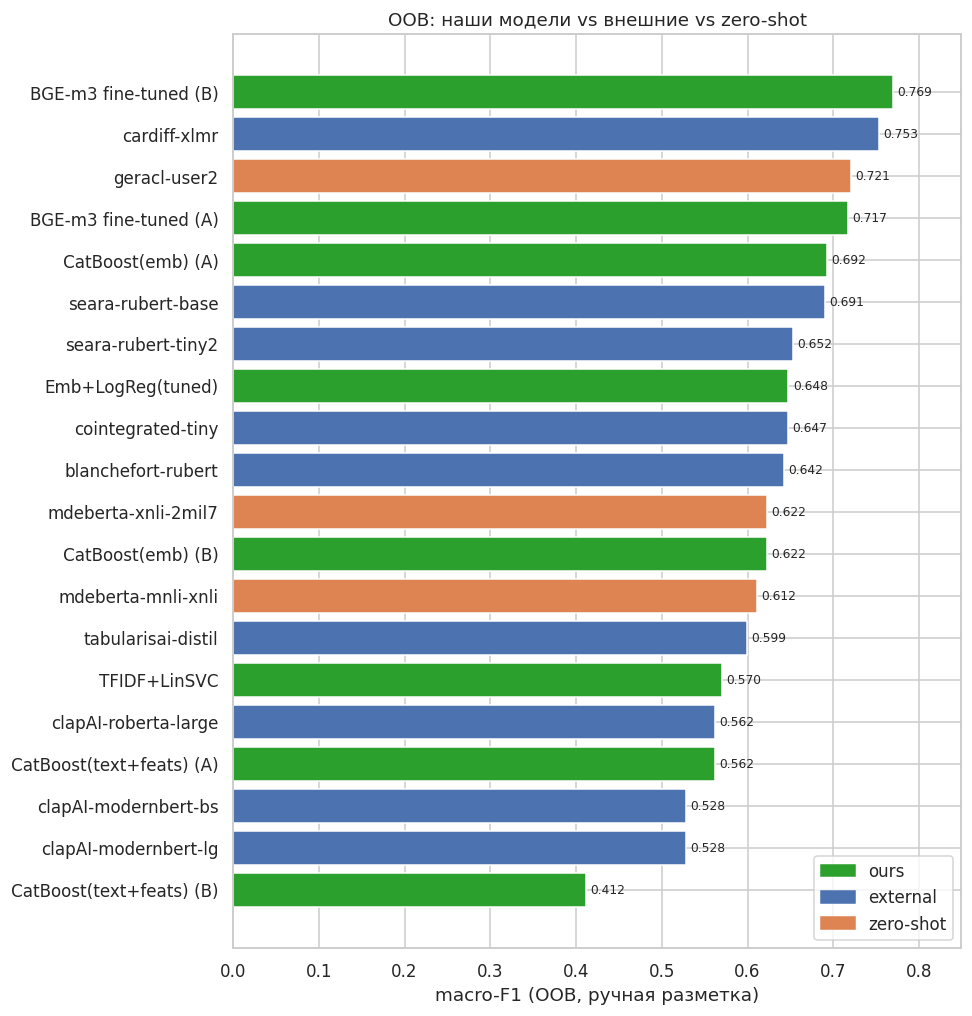

Лучшие по семействам:
  ours      : BGE-m3 fine-tuned (B)  macro-F1=0.769
  external  : cardiff-xlmr  macro-F1=0.753
  zero-shot : geracl-user2  macro-F1=0.721


In [26]:
from matplotlib.patches import Patch

t = tbl.sort_values("macro_f1")
colors = [PAL.get(g, "#777") for g in t["group"]]
fig, ax = plt.subplots(figsize=(9, 0.42 * len(t) + 1))
ax.barh(t["model"], t["macro_f1"], color=colors)
for yi, v in enumerate(t["macro_f1"]):
    ax.text(v + 0.005, yi, f"{v:.3f}", va="center", fontsize=8)
ax.set_xlim(0, max(0.7, t["macro_f1"].max() + 0.08))
ax.set_xlabel("macro-F1 (OOB, ручная разметка)")
ax.set_title("OOB: наши модели vs внешние vs zero-shot")
ax.legend(handles=[Patch(color=c, label=l) for l, c in PAL.items()], loc="lower right")
savefig("14_oob_comparison"); plt.show()

print("Лучшие по семействам:")
for g in ["ours", "external", "zero-shot"]:
    sub = tbl[tbl["group"] == g]
    if len(sub):
        r = sub.iloc[0]
        print(f"  {g:10s}: {r['model']}  macro-F1={r['macro_f1']:.3f}")

## 3. Матрицы ошибок лучших моделей

Для лучшей модели каждого семейства смотрим, где путаница: типичная проблема на соцсетях — класс `neutral` (модели тянут его в negative/positive).

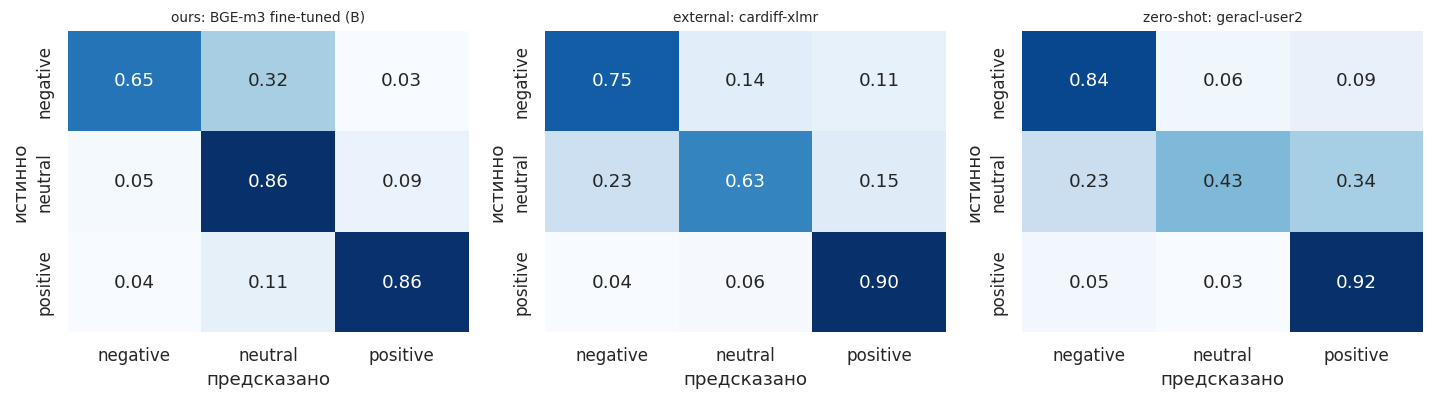

In [27]:
best = {g: tbl[tbl["group"] == g].iloc[0]["model"]
        for g in ["ours", "external", "zero-shot"] if (tbl["group"] == g).any()}
fig, axes = plt.subplots(1, len(best), figsize=(4.4 * len(best), 3.8))
if len(best) == 1:
    axes = [axes]
for a, (g, mname) in zip(axes, best.items()):
    sub = preds[preds["model"] == mname]
    c = confusion_matrix(sub["y_true"], sub["y_pred"], labels=LABELS)
    sns.heatmap(c / c.sum(1, keepdims=True), annot=True, fmt=".2f", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS, ax=a, cbar=False)
    a.set_title(f"{g}: {mname}", fontsize=9); a.set_xlabel("предсказано"); a.set_ylabel("истинно")
savefig("15_oob_confusion"); plt.show()

## 4. Поклассовое качество и масштаб domain shift

Слева — F1 по каждому классу для всех моделей (видно, какой класс «проседает»). Справа — насколько наши модели теряют в качестве при переходе с in-domain теста на OOB соцсети.

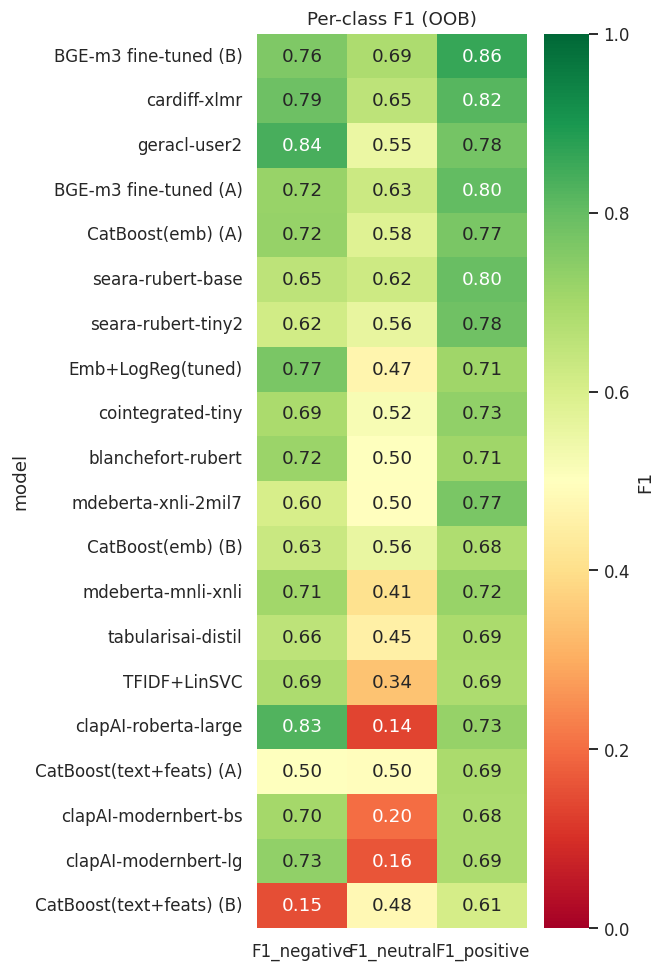

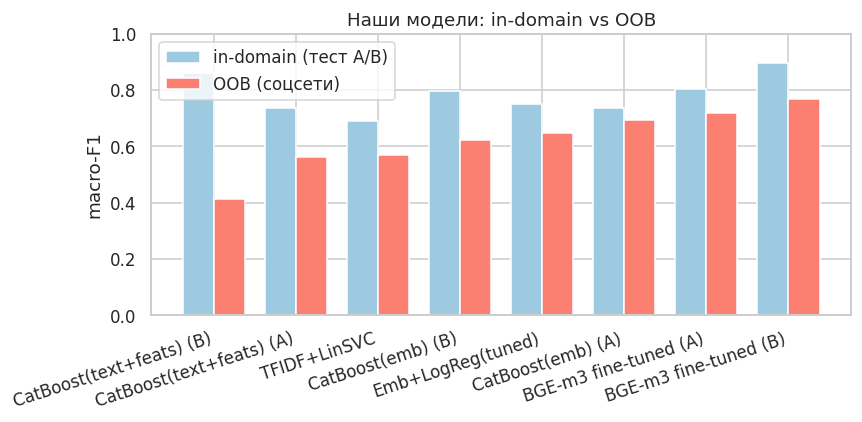

,model,in_domain_f1,macro_f1,oob_drop
19,CatBoost(text+feats) (B),0.859,0.412,0.447
16,CatBoost(text+feats) (A),0.736,0.562,0.174
14,TFIDF+LinSVC,0.689,0.570,0.119
11,CatBoost(emb) (B),0.796,0.622,0.174
7,Emb+LogReg(tuned),0.751,0.648,0.103
4,CatBoost(emb) (A),0.737,0.692,0.045
3,BGE-m3 fine-tuned (A),0.805,0.717,0.088
0,BGE-m3 fine-tuned (B),0.897,0.769,0.128


In [28]:
H = tbl.set_index("model")[["F1_negative", "F1_neutral", "F1_positive"]]
fig, ax = plt.subplots(figsize=(6.2, 0.4 * len(H) + 1))
sns.heatmap(H, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1, ax=ax, cbar_kws={"label": "F1"})
ax.set_title("Per-class F1 (OOB)"); ax.set_xlabel(""); plt.yticks(rotation=0)
savefig("16_oob_perclass"); plt.show()

ours = tbl[tbl["group"] == "ours"].dropna(subset=["in_domain_f1"]).sort_values("macro_f1")
if len(ours):
    x = np.arange(len(ours)); w = 0.38
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x - w / 2, ours["in_domain_f1"], w, label="in-domain (тест A/B)", color="#9ecae1")
    ax.bar(x + w / 2, ours["macro_f1"], w, label="OOB (соцсети)", color="#fb8072")
    ax.set_xticks(x); ax.set_xticklabels(ours["model"], rotation=18, ha="right")
    ax.set_ylabel("macro-F1"); ax.set_ylim(0, 1); ax.set_title("Наши модели: in-domain vs OOB")
    ax.legend(); savefig("17_oob_drop"); plt.show()
    display(ours[["model", "in_domain_f1", "macro_f1", "oob_drop"]].round(3))

## Итоги части 4 (адаптивные)

In [29]:
# Итоги части 4 формируются автоматически из OOB-таблицы tbl.
from IPython.display import Markdown, display

_t = tbl.copy()
_md = ["### Итоги части 4 (OOB, обновляются при перезапуске)", ""]

b = _t.iloc[0]
_md.append(f"**Лучшая модель на OOB:** {b['model']} — macro-F1 {b['macro_f1']:.3f}, accuracy {b['accuracy']:.3f}.")

_grp = []
for g in ["ours", "external", "zero-shot"]:
    sub = _t[_t["group"] == g]
    if len(sub):
        r = sub.iloc[0]
        _grp.append(f"{g} — {r['model']} ({r['macro_f1']:.3f})")
if _grp:
    _md.append("**Лучшие по семействам:** " + "; ".join(_grp) + ".")

_ours = _t[_t["group"] == "ours"]
if len(_ours):
    _md.append("**Наши модели (macro-F1):** "
               + " > ".join(f"{r['model']} {r['macro_f1']:.3f}" for _, r in _ours.iterrows()) + ".")

_ds = _t.dropna(subset=["in_domain_f1"])
if len(_ds):
    lo = _ds.loc[_ds["oob_drop"].idxmin()]
    hi = _ds.loc[_ds["oob_drop"].idxmax()]
    _md.append(f"**Изменение in-domain→OOB:** наименьшее падение у {lo['model']} "
               f"({lo['in_domain_f1']:.3f}→{lo['macro_f1']:.3f}, {lo['macro_f1'] - lo['in_domain_f1']:+.3f}); "
               f"наибольшее у {hi['model']} ({hi['in_domain_f1']:.3f}→{hi['macro_f1']:.3f}, {hi['macro_f1'] - hi['in_domain_f1']:+.3f}).")

_cls = _t[["F1_negative", "F1_neutral", "F1_positive"]].mean().sort_values()
_md.append("**Средний F1 по классам (по всем моделям):** "
           + ", ".join(f"{c.replace('F1_', '')} {v:.3f}" for c, v in _cls.items())
           + f"; самый трудный — {_cls.index[0].replace('F1_', '')}.")

display(Markdown("\n\n".join(_md)))

### Итоги части 4 (OOB, обновляются при перезапуске)



**Лучшая модель на OOB:** BGE-m3 fine-tuned (B) — macro-F1 0.769, accuracy 0.765.

**Лучшие по семействам:** ours — BGE-m3 fine-tuned (B) (0.769); external — cardiff-xlmr (0.753); zero-shot — geracl-user2 (0.721).

**Наши модели (macro-F1):** BGE-m3 fine-tuned (B) 0.769 > BGE-m3 fine-tuned (A) 0.717 > CatBoost(emb) (A) 0.692 > Emb+LogReg(tuned) 0.648 > CatBoost(emb) (B) 0.622 > TFIDF+LinSVC 0.570 > CatBoost(text+feats) (A) 0.562 > CatBoost(text+feats) (B) 0.412.

**Изменение in-domain→OOB:** наименьшее падение у CatBoost(emb) (A) (0.737→0.692, -0.045); наибольшее у CatBoost(text+feats) (B) (0.859→0.412, -0.447).

**Средний F1 по классам (по всем моделям):** neutral 0.475, negative 0.673, positive 0.734; самый трудный — neutral.